# Sprint 2 — Visualização Operacional e Representação do Ativo
## Challenge FIAP × Forzy | Processamento de Linguagem Natural

---

### Equipe

| Nome | RM |
|------|----|
| Lucca Phelipe Masini | 564121 |
| Luiz Henrique Poss | 562177 |
| Felipe Stefani Honorato | 563380 |
| Igor Paixão Sarak | 563726 |
| Bernardo Braga Perobeli | 562468 |

---

### Contexto

Esta Sprint 2 dá continuidade ao trabalho da Sprint 1, na qual construímos o **corpus textual estruturado** dos ativos industriais. Agora, transformamos esse corpus em **representação vetorial (embeddings)**, construímos um **módulo de recuperação semântica** e enriquecemos a interface do digital twin com **descrições em linguagem natural** do estado operacional dos motores.

O objetivo é permitir que um operador da Forzy faça perguntas como _"qual o motor da área de produção?"_ ou _"tem algum equipamento com sobretemperatura?"_ e receba respostas relevantes recuperadas por similaridade semântica, acompanhadas de descrições textuais do estado atual do ativo.

> **Integração com a Sprint 1:** o corpus de entrada é exatamente o `corpus_sprint1_v1.0.0.json` produzido pela sprint anterior — mantemos a mesma naming convention, os mesmos 10 documentos sobre 3 motores (WEG MOT-PROD-001, Siemens MOT-UTIL-003, ABB MOT-COMP-007) e a mesma decisão de design quanto a normalização textual. Para garantir execução autônoma no Colab, fornecemos também um fallback inline com o mesmo conteúdo.

---

### Estrutura do Notebook

| # | Seção | Descrição |
|---|-------|-----------|
| 1 | Instalação e Importações | sentence-transformers, FAISS, paleta de cores Forzy |
| 2 | Carregamento do Corpus | Integração com artefatos da Sprint 1 (com fallback inline) |
| 3 | Modelo de Embeddings | Escolha e justificativa (idioma + domínio industrial) |
| 4 | Geração de Vetores | Composição dos textos e encoding |
| 5 | Indexação FAISS | Estrutura de recuperação por similaridade |
| 5b | Embedding por Equipamento | Índice agregado complementar (1 vetor por motor) |
| 6 | Sinônimos Operador→Técnico | Tratamento de vocabulário coloquial |
| 7 | Módulo de Consulta Semântica | Função de busca + demos + Exemplo 1 do enunciado |
| 8 | Consultas-Teste e Ground Truth | 14 queries (incluindo as 2 exemplo do enunciado) |
| 9 | Métricas de Avaliação | Precision/Recall/F1 em k=1,3,5 + MRR |
| 9b | Análise de Erros | Diagnóstico das queries com baixa performance |
| 10 | Estado Operacional Simulado | Leituras dos sensores em tempo real |
| 11 | Templates de NLG | Geração de descrições em linguagem natural |
| 11b | Consulta Estruturada | Filtro + ranking (resolve Exemplo 2 do enunciado) |
| 12 | Demo Integrada | Operador → consulta → resposta enriquecida |
| 13 | Exportação dos Artefatos | Índice FAISS, embeddings, métricas |
| 13b | Verificação de Persistência | Reload do índice salvo |
| 14 | Decisões Documentadas | Regras de design D007–D015 |
| 15 | Empacotamento para Entrega | Gera .md + ZIP + downloads no Colab |


---
## 1. Instalação e Importações

In [ ]:
# Dependencias da Sprint 2
!pip install sentence-transformers faiss-cpu pandas numpy matplotlib seaborn -q

import json
import re
import random
from collections import Counter
from datetime import date, datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sentence_transformers import SentenceTransformer
import faiss

# Reprodutibilidade — fixar TODAS as fontes de aleatoriedade do encoder
random.seed(42)
np.random.seed(42)
try:
    import torch
    torch.manual_seed(42)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(42)
except ImportError:
    pass

# Paleta de cores Forzy (consistente com Sprint 1)
VERDE   = '#1D9E75'
ROXO    = '#534AB7'
LARANJA = '#F59E0B'
VERMELHO = '#EF4444'
CINZA   = '#6B7280'

print('Ambiente Sprint 2 configurado')
print('   sentence-transformers + FAISS prontos')
print('   Reprodutibilidade fixada (seed=42)')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 32.5 MB/s eta 0:00:00
Ambiente Sprint 2 configurado
   sentence-transformers + FAISS prontos
   Reprodutibilidade fixada (seed=42)


---
## 2. Carregamento do Corpus da Sprint 1

O corpus produzido na Sprint 1 está em `corpus/processed/corpus_sprint1_v1.0.0.json`. Caso o arquivo não esteja disponível (ex: execução standalone no Colab sem upload), o notebook usa um **fallback inline** com exatamente os mesmos 10 documentos pré-processados — garantindo execução autônoma sem perder a integração conceitual com a Sprint 1.

In [ ]:
# Corpus inline (espelho do que a Sprint 1 produziu apos normalizacao)
# Em execucao local com o arquivo da Sprint 1 disponivel, este eh um fallback.

CORPUS_INLINE = [
    {
        'id': 'PLQ-001', 'tag': 'MOT-PROD-001', 'fonte': 'placa', 'idioma_detectado': 'pt',
        'texto_normalizado': 'WEG Motor de Inducao Trifasico modelo W22 Plus 100L. Potencia 4,0 kW (5,5 HP). Rotacao 1740 RPM. Tensao 220/380/440V Delta/Y. Corrente 14,5/8,4/7,2 A. Frequencia 60 Hz. Fator de potencia 0,82. Rendimento 87,5%. Classe de isolamento F. IP55. IE3. Fator de servico 1,15. Regime S1. Numero de serie WEG2024-004521.',
    },
    {
        'id': 'PLQ-002', 'tag': 'MOT-UTIL-003', 'fonte': 'placa', 'idioma_detectado': 'en',
        'texto_normalizado': 'Siemens 3-Phase Induction Motor type 1LA7 133-4AA. Output 7,5 kW. Speed 1455 RPM. Voltage 380V Y. Current 16,2 A. Frequency 50 Hz. cos phi 0,85. Efficiency 89,8%. Insulation class F. Protection IP55. IE2. Duty S1. Ambient 40C. Serial SIE-2023-78432.',
    },
    {
        'id': 'PLQ-003', 'tag': 'MOT-COMP-007', 'fonte': 'placa', 'idioma_detectado': 'pt',
        'texto_normalizado': 'ABB Motor Assincrono Trifasico referencia M3BP 200 MLA 4. Potencia nominal 30 kW. Velocidade 1480 RPM. Tensao nominal 380/660 V (D/Y). Corrente nominal 59,5/34,3 A. Frequencia 50 Hz. Fator de potencia 0,88. Eficiencia 92,1%. Isolamento Classe F. Grau de protecao IP55. Eficiencia IE3. Servico Continuo S1. Numero de serie ABB-30KW-2022-11547.',
    },
    {
        'id': 'MAN-001', 'tag': 'MOT-PROD-001', 'fonte': 'manual', 'idioma_detectado': 'pt',
        'texto_normalizado': 'Instrucoes de instalacao e manutencao do Motor W22 Plus. Os rolamentos devem ser lubrificados a cada 2.000 horas de operacao ou 6 meses. A vibracao maxima permitida eh de 2,8 mm/s RMS conforme ISO 10816. O torque de aperto dos parafusos de fixacao deve ser de 25 N.m. Verifique o alinhamento do acoplamento: desalinhamento angular maximo de 0,1 mm e desalinhamento paralelo maximo de 0,05 mm. Operate within ambient temperature -20C to +40C. Bearing type 6308-2Z Drive End / 6206-2Z Non-Drive End. Corrente de partida (Ia/In) 6,5x a corrente nominal.',
    },
    {
        'id': 'MAN-002', 'tag': 'MOT-UTIL-003', 'fonte': 'manual', 'idioma_detectado': 'en',
        'texto_normalizado': 'Siemens 1LA7 Series Installation and Maintenance Manual. Insulation resistance must be measured before commissioning. Minimum insulation resistance 100 MOhm at 1000V DC 60 seconds. Regreasing interval 3500 hours for bearings under normal load. Vibration limits per ISO 10816 Class B less than 2.8 mm/s RMS. During overload conditions current may reach 6x rated current. Temperatura maxima do enrolamento 155C Classe F. Verificar folga axial do eixo maximo 0,3 mm.',
    },
    {
        'id': 'CAD-001', 'tag': 'MOT-PROD-001', 'fonte': 'cadastro', 'idioma_detectado': 'pt',
        'texto_normalizado': 'Equipamento Motor eletrico de inducao trifasico. TAG MOT-PROD-001. Localizacao Planta 1 Area de Producao Linha 3. Aplicacao Acionamento de bomba centrifuga de agua industrial. Fabricante WEG. Modelo W22 Plus 100L. Potencia 4 kW. Tensao 380 V. Corrente 8,4 A. RPM 1740. Data de instalacao 15/02/2024. Proxima manutencao preventiva 15/08/2024. Responsavel Joao Silva.',
    },
    {
        'id': 'CAD-002', 'tag': 'MOT-COMP-007', 'fonte': 'cadastro', 'idioma_detectado': 'pt',
        'texto_normalizado': 'Maquina Motor Assincrono Trifasico ABB. Identificacao MOT-COMP-007. Setor Utilidades Compressores. Funcao Aciona compressor de parafuso 30 kW. Fabricante ABB. Numero de serie ABB-30KW-2022-11547. Potencia 30 kW. Tensao 380V. Corrente 59,5A. Velocidade 1480 RPM. IP 55. Classe de isolamento F. Data de inicio de operacao 01/03/2022.',
    },
    {
        'id': 'LOG-001', 'tag': 'MOT-PROD-001', 'fonte': 'log', 'idioma_detectado': 'pt',
        'texto_normalizado': 'Ordem de servico OS#2024-0892 do MOT-PROD-001. Data 10/04/2025. Tipo manutencao corretiva. Relato: Motor apresentou vibracao elevada (4,2 mm/s) e ruido anormal. Operador relata aumento progressivo de ruido nas ultimas 72 horas. Temperatura da carcaca medida 85C, limite 80C. Acao: Substituicao do rolamento DE (lado do acionamento) 6308-2Z por desgaste. Lubrificacao do rolamento NDE (lado oposto ao acionamento) realizada preventivamente. Pos-manutencao: vibracao 1,2 mm/s, temperatura 68C. Motor normalizado. Tecnico Carlos Mendes. Duracao 3 horas.',
    },
    {
        'id': 'LOG-002', 'tag': 'MOT-COMP-007', 'fonte': 'log', 'idioma_detectado': 'pt',
        'texto_normalizado': 'Ordem de servico OS#2025-0124 do MOT-COMP-007. Data 05/04/2025. Tipo manutencao preventiva. Atividade: Manutencao preventiva periodica 6 meses. Verificacao de tensao 381V (ok). Corrente 58,8A (ok). Resistencia de isolamento (megometria) 850 MOhm (ok, minimo 100 MOhm). Vibracao medida 2,1 mm/s RMS, limite ISO 10816 Classe B 2,8 mm/s. Relubrificacao dos rolamentos realizada com graxa Mobil Polyrex EM. Inspecao visual sem anomalias. Ventilador limpo. Proxima manutencao preventiva agendada 05/10/2025. Tecnico Ana Ferreira. Duracao 1,5 horas.',
    },
    {
        'id': 'LOG-003', 'tag': 'MOT-UTIL-003', 'fonte': 'log', 'idioma_detectado': 'pt',
        'texto_normalizado': 'Alarme SCADA do MOT-UTIL-003 em 2025-04-17 14:32:11. Tipo Sobretemperatura. Temperatura da bobina 162C, threshold 155C. Corrente fase A 18,4A. Corrente fase B 17,1A. Corrente fase C 18,9A. Desbalanceamento de corrente 5,2%, limite 3%. Motor desligado automaticamente pelo rele de protecao. Inspecao indicou obstrucao parcial da entrada de ar do ventilador. Causa provavel: falha de ventilacao por acumulo de po. Motor recolocado em operacao apos limpeza. Monitorar temperatura nas proximas 24 horas.',
    },
]


def carregar_corpus():
    """Tenta carregar o JSON da Sprint 1; senao, usa o fallback inline."""
    caminho_sprint1 = Path('corpus/processed/corpus_sprint1_v1.0.0.json')
    if caminho_sprint1.exists():
        with open(caminho_sprint1, 'r', encoding='utf-8') as f:
            dados = json.load(f)
        corpus = [
            {
                'id': d['id'], 'tag': d['tag'], 'fonte': d['fonte'],
                'idioma_detectado': d['idioma_detectado'],
                'texto_normalizado': d['texto_normalizado'],
            }
            for d in dados['documentos']
        ]
        print(f'Corpus carregado de {caminho_sprint1}')
        print(f'   Versao: {dados["metadata"]["versao"]} | Documentos: {len(corpus)}')
        return corpus
    print('Arquivo da Sprint 1 nao encontrado — usando CORPUS_INLINE')
    return CORPUS_INLINE


corpus = carregar_corpus()
df_corpus = pd.DataFrame(corpus)
print(f'\nDocumentos: {len(corpus)}')
print(f'Distribuicao por fonte: {dict(Counter(d["fonte"] for d in corpus))}')
print(f'Distribuicao por idioma: {dict(Counter(d["idioma_detectado"] for d in corpus))}')
print(f'Motores unicos: {sorted(set(d["tag"] for d in corpus))}')


Arquivo da Sprint 1 nao encontrado — usando CORPUS_INLINE

Documentos: 10
Distribuicao por fonte: {'placa': 3, 'manual': 2, 'cadastro': 2, 'log': 3}
Distribuicao por idioma: {'pt': 8, 'en': 2}
Motores unicos: ['MOT-COMP-007', 'MOT-PROD-001', 'MOT-UTIL-003']


---
## 3. Modelo de Embeddings — Escolha e Justificativa

### Modelo escolhido: `paraphrase-multilingual-MiniLM-L12-v2`

Avaliamos cinco alternativas — três multilíngues de SBERT, um monolíngue PT (BERTimbau) e a possibilidade de modelo de domínio industrial — antes de definir o modelo de produção:

| Modelo | Dim | Tamanho | Idiomas | Treino | Decisão |
|---|---|---|---|---|---|
| `all-MiniLM-L6-v2` | 384 | 22 MB | Apenas EN | NLI + paráfrase EN | ❌ Corpus tem ~85% PT — monolíngue EN inviabiliza |
| `neuralmind/bert-base-portuguese-cased` (BERTimbau) | 768 | 420 MB | Apenas PT | MLM em brWaC (PT) | ⚠️ PT excelente mas (a) não cobre EN; (b) não foi *fine-tuned* para retrieval/paráfrase — precisaria treino adicional |
| `paraphrase-multilingual-MiniLM-L12-v2` | 384 | 118 MB | 50+ (incl. PT/EN) | Paráfrase multilíngue | ✅ **Selecionado** |
| `distiluse-base-multilingual-cased-v2` | 512 | 480 MB | 15 | USE + KD multilíngue | ⚠️ 4× maior, ganho marginal no nosso volume |
| Modelo *domain-specific* industrial (PT) | — | — | — | — | ❌ Não há modelo mainstream pré-treinado em PT industrial; *fine-tuning* fica como passo de produção |

### Justificativa do modelo escolhido frente ao **idioma do corpus**

A Sprint 1 mostrou que o corpus tem **8 documentos em PT** e **2 em EN** (manuais Siemens 1LA7 e overview ABB M3BP). Um modelo treinado em 50+ idiomas processa ambos sem necessidade de roteamento por idioma. Para um modelo monolíngue como BERTimbau, teríamos que (a) traduzir os manuais (perda de informação técnica e introdução de vocabulário não-padronizado) ou (b) manter dois índices separados (complexidade operacional + dificuldade de busca cross-lingual quando o operador escreve em PT mas a fonte está em EN). O `paraphrase-multilingual-MiniLM-L12-v2` foi treinado com **alinhamento cross-lingual** via destilação a partir de um modelo *teacher* em EN — isso significa que _"vibração elevada"_ (PT) e _"high vibration"_ (EN) ficam próximos no espaço vetorial.

### Justificativa do modelo escolhido frente ao **domínio técnico industrial**

1. **Treinamento em *paraphrase identification*** — o modelo foi *fine-tuned* sobre pares de paráfrases (>50 milhões de pares), otimizando explicitamente a similaridade entre formulações diferentes do mesmo conceito. Isso é exatamente o que precisamos no chão de fábrica: o operador escreve _"motor quente"_ e queremos recuperar documentos que mencionam _"sobretemperatura"_, _"temperatura elevada"_ ou _"alarme térmico"_. BERTimbau é treinado apenas em MLM (*masked language modeling*) — bom para representação geral, mas não otimizado para retrieval/similaridade.

2. **Robustez à terminologia industrial via normalização da Sprint 1** — embora o modelo seja generalista, **a Sprint 1 já preparou o corpus** para reduzir o impacto do vocabulário técnico desconhecido: abreviações foram expandidas (`Cl.Isol.` → `classe de isolamento`), unidades foram padronizadas (`4kw` → `4 kW`) e fabricantes foram unificados (`W.E.G.` → `WEG`). Isso reduz a chance de o modelo encontrar tokens fora-de-vocabulário no domínio.

3. **Trade-off tamanho × performance ideal** — 118 MB roda em CPU de Colab gratuito sem GPU, com latência de inferência **< 50 ms por query**. Modelos maiores (`mpnet-base`, `distiluse`) trariam ganhos marginais em retrieval de corpus pequeno mas com custo computacional 4-10× maior, inviabilizando deploy em edge devices da planta industrial — cenário-alvo da Forzy.

4. **Limitação assumida (vocabulário técnico muito específico)** — o modelo não conhece *a priori* códigos como `6308-2Z` (rolamento ZZ-shield), `S1` (regime contínuo IEC 60034), `IE3` (classe de eficiência) ou `IP55` (grau de proteção). Mitigamos isso de duas formas: (a) a normalização da Sprint 1 já expandiu boa parte; (b) o dicionário de sinônimos (Seção 6) curou as variações operador↔técnico mais comuns. Para a Sprint 2 (retrieval por similaridade), isso é suficiente. **Em produção**, o caminho seria *fine-tuning* incremental sobre o corpus real da Forzy assim que ele for disponibilizado — manteríamos a arquitetura e o pipeline, apenas re-treinando os pesos.

### Características do espaço vetorial

- **Dimensão:** 384
- **Normalização:** L2 (norma = 1) → permite usar *inner product* como métrica equivalente a *cosine similarity*
- **Range de similaridade:** [-1, 1]; valores típicos em retrieval bem-sucedido > 0.4
- **Alinhamento cross-lingual:** garantido pelo treino de destilação multilíngue (Reimers & Gurevych, 2020)


In [ ]:
MODEL_NAME = 'paraphrase-multilingual-MiniLM-L12-v2'
print(f'Carregando modelo {MODEL_NAME}...')
print('   (~118 MB no primeiro download)')

model = SentenceTransformer(MODEL_NAME)

print(f'\nModelo carregado')
print(f'   Dimensao dos embeddings: {model.get_sentence_embedding_dimension()}')
print(f'   Max sequence length: {model.max_seq_length} tokens')
print(f'   Device: {model.device}')


Carregando modelo paraphrase-multilingual-MiniLM-L12-v2...
   (~118 MB no primeiro download)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


Modelo carregado
   Dimensao dos embeddings: 384
   Max sequence length: 128 tokens
   Device: cpu


/tmp/ipykernel_3788/2059048145.py:8: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f'   Dimensao dos embeddings: {model.get_sentence_embedding_dimension()}')


---
## 4. Composição dos Textos e Geração de Vetores

Em vez de embedir cada campo isoladamente (TAG, descrição, localização separados), compomos uma **string única por documento** que combina os elementos contextuais:

```
[<FONTE>] TAG <id>. <texto_normalizado>
```

**Por que essa composição?**
- A TAG explícita ajuda em consultas que mencionam o identificador (ex: _"status do MOT-PROD-001"_).
- A fonte (placa/manual/cadastro/log) permite que o operador filtre semanticamente por tipo de documento (_"a placa do compressor"_).
- O texto_normalizado preserva todos os parâmetros técnicos relevantes.

**Decisão crítica — texto_normalizado vs tokens lematizados:**

A Sprint 1 produziu dois artefatos textuais por documento: `texto_normalizado` (frase natural após normalização) e `tokens_lematizados` (bag-of-words após stopwords + lematização). Para embeddings com sentence-transformers, usamos o **texto_normalizado**, porque:

1. Transformers foram treinados em texto natural — perdem qualidade com bag-of-tokens
2. A estrutura sintática preserva relações que o bag-of-words destruiu
3. Os tokens lematizados continuam úteis para análise estatística e indexação invertida tradicional

Decisão registrada no documento de decisões da sprint (D008).

In [ ]:
def documento_para_texto_embedding(doc):
    """Compoe a string que sera embedida para o documento.
    Formato: [FONTE] TAG <id>. <texto_normalizado>
    """
    return f"[{doc['fonte'].upper()}] TAG {doc['tag']}. {doc['texto_normalizado']}"


textos_embedding = [documento_para_texto_embedding(d) for d in corpus]

print(f'Compostos {len(textos_embedding)} textos para embedding\n')
print('Exemplo (primeiro documento):')
print('-' * 70)
print(textos_embedding[0][:280] + '...')
print('-' * 70)

# Encoding com normalize_embeddings=True (vetores L2-normalizados)
print('\nGerando embeddings...')
embeddings = model.encode(
    textos_embedding,
    normalize_embeddings=True,
    show_progress_bar=True,
    convert_to_numpy=True,
).astype('float32')

print(f'\nEmbeddings gerados:')
print(f'   Shape:  {embeddings.shape}')
print(f'   Dtype:  {embeddings.dtype}')
print(f'   Norma L2 media: {np.linalg.norm(embeddings, axis=1).mean():.4f} (esperado 1.0)')
print(f'   Min/Max valor: {embeddings.min():.3f} / {embeddings.max():.3f}')


Compostos 10 textos para embedding

Exemplo (primeiro documento):
----------------------------------------------------------------------
[PLACA] TAG MOT-PROD-001. WEG Motor de Inducao Trifasico modelo W22 Plus 100L. Potencia 4,0 kW (5,5 HP). Rotacao 1740 RPM. Tensao 220/380/440V Delta/Y. Corrente 14,5/8,4/7,2 A. Frequencia 60 Hz. Fator de potencia 0,82. Rendimento 87,5%. Classe de isolamento F. IP55. IE3. Fator de...
----------------------------------------------------------------------

Gerando embeddings...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Embeddings gerados:
   Shape:  (10, 384)
   Dtype:  float32
   Norma L2 media: 1.0000 (esperado 1.0)
   Min/Max valor: -0.186 / 0.177


---
## 5. Indexação FAISS

Usamos **`IndexFlatIP`** do FAISS — busca exata via *inner product*. Como os embeddings estão L2-normalizados, o produto interno é equivalente à *cosine similarity*.

**Por que `IndexFlatIP` e não algo mais avançado?**
- **Corpus pequeno (10 documentos):** busca exata custa O(n·d) ≈ 3.840 operações por query — irrelevante.
- **Recall garantido:** índices aproximados (HNSW, IVF) trocam precisão por velocidade; sem necessidade aqui.
- **Sem overhead de construção:** não há treino do índice nem hyperparâmetros para ajustar.

**Plano de migração para produção:**
- Até ~10 mil docs: continuar com IndexFlatIP
- 10 mil – 1 milhão docs: migrar para `IndexHNSWFlat` (grafo navegável, ~95% recall com 10-50× speedup)
- Acima de 1 milhão docs: avaliar `IndexIVFPQ` (clusterização + quantização)

In [ ]:
dim = embeddings.shape[1]
faiss_index = faiss.IndexFlatIP(dim)
faiss_index.add(embeddings)

print('Indice FAISS construido')
print(f'   Tipo:        IndexFlatIP (exact search via inner product)')
print(f'   Dimensao:    {dim}')
print(f'   Vetores indexados: {faiss_index.ntotal}')

# Sanity check: buscar pelo proprio primeiro vetor deve retornar ele mesmo no top-1
scores_sanity, indices_sanity = faiss_index.search(embeddings[:1], 3)
print(f'\nSanity check (busca pelo proprio embedding[0]):')
for rank, (idx, score) in enumerate(zip(indices_sanity[0], scores_sanity[0]), 1):
    print(f'   {rank}. {corpus[idx]["id"]} (score={score:.4f})')


Indice FAISS construido
   Tipo:        IndexFlatIP (exact search via inner product)
   Dimensao:    384
   Vetores indexados: 10

Sanity check (busca pelo proprio embedding[0]):
   1. PLQ-001 (score=1.0000)
   2. PLQ-003 (score=0.8656)
   3. PLQ-002 (score=0.8205)


---
## 5b. Embedding Agregado por Equipamento (Visão Consolidada)

Além do índice **por documento** (10 vetores — Sec 5), construímos um índice **por equipamento** (3 vetores — um por motor). Esse índice agregado responde à interpretação literal do enunciado — _"embeddings dos campos textuais do cadastro do equipamento"_ — onde o **cadastro consolidado** do ativo é uma única entidade conceitual, mesmo que sua descrição textual venha de múltiplas fontes (placa + manual + cadastro + log).

**Como agregamos?**

Para cada motor, calculamos a **média dos vetores dos documentos** que o descrevem, renormalizamos para norma L2 = 1, e indexamos no FAISS. A média de vetores L2-normalizados é uma operação padrão (Reimers & Gurevych, 2019) que captura o "centróide semântico" do equipamento.

**Quando usar cada índice?**

| Caso de uso | Índice |
|---|---|
| "Mostre tudo sobre o motor da bomba" | **Por equipamento** — uma única resposta sumária |
| "Qual placa do MOT-COMP-007?" | Por documento — preserva fonte específica |
| Avaliação geral / queries do enunciado | Por documento (padrão) |
| Dashboard de visão geral por ativo | Por equipamento |

A decisão de manter **ambos** os índices está documentada em **D013** (Seção 14).

In [ ]:
# Embeddings agregados por equipamento — media dos vetores dos documentos de cada motor
from collections import defaultdict

vetores_por_tag = defaultdict(list)
docs_por_tag = defaultdict(list)
for i, doc in enumerate(corpus):
    vetores_por_tag[doc['tag']].append(embeddings[i])
    docs_por_tag[doc['tag']].append(doc['id'])

tags_unicas_sorted = sorted(vetores_por_tag.keys())

# Media dos vetores e renormalizacao L2
embeddings_por_tag = np.array([
    np.mean(vetores_por_tag[tag], axis=0)
    for tag in tags_unicas_sorted
])
embeddings_por_tag = embeddings_por_tag / np.linalg.norm(embeddings_por_tag, axis=1, keepdims=True)
embeddings_por_tag = embeddings_por_tag.astype('float32')

# Indice FAISS agregado
faiss_index_por_tag = faiss.IndexFlatIP(dim)
faiss_index_por_tag.add(embeddings_por_tag)

print('Indice agregado por equipamento construido')
print(f'   Vetores: {faiss_index_por_tag.ntotal} (1 por motor unico)')
print()
for i, tag in enumerate(tags_unicas_sorted):
    print(f'   [{i}] {tag} <- agregacao de {docs_por_tag[tag]}')


def buscar_por_equipamento(query: str, k: int = 3, verbose: bool = True):
    """Busca no indice agregado — retorna ate k motores (nao documentos)."""
    q_emb = model.encode([expandir_query(query)], normalize_embeddings=True,
                          convert_to_numpy=True).astype('float32') if 'expandir_query' in globals() else \
            model.encode([query], normalize_embeddings=True, convert_to_numpy=True).astype('float32')
    scores, indices = faiss_index_por_tag.search(q_emb, k)
    resultados = []
    for rank, (idx, score) in enumerate(zip(indices[0], scores[0]), 1):
        resultados.append({
            'rank': rank,
            'tag': tags_unicas_sorted[idx],
            'score': float(score),
            'documentos_origem': docs_por_tag[tags_unicas_sorted[idx]],
        })
    if verbose:
        print(f"\nBusca por equipamento (top-{k}): '{query}'")
        for r in resultados:
            print(f"   {r['rank']}. {r['tag']} (score={r['score']:.4f}) <- {r['documentos_origem']}")
    return resultados


# Demo: mesma query, dois indices
print()
print('=' * 70)
print('COMPARACAO ENTRE OS DOIS INDICES — query: "motor da bomba"')
print('=' * 70)
buscar_por_equipamento('motor da bomba', k=3)


Indice agregado por equipamento construido
   Vetores: 3 (1 por motor unico)

   [0] MOT-COMP-007 <- agregacao de ['PLQ-003', 'CAD-002', 'LOG-002']
   [1] MOT-PROD-001 <- agregacao de ['PLQ-001', 'MAN-001', 'CAD-001', 'LOG-001']
   [2] MOT-UTIL-003 <- agregacao de ['PLQ-002', 'MAN-002', 'LOG-003']

COMPARACAO ENTRE OS DOIS INDICES — query: "motor da bomba"

Busca por equipamento (top-3): 'motor da bomba'
   1. MOT-PROD-001 (score=0.5151) <- ['PLQ-001', 'MAN-001', 'CAD-001', 'LOG-001']
   2. MOT-UTIL-003 (score=0.4272) <- ['PLQ-002', 'MAN-002', 'LOG-003']
   3. MOT-COMP-007 (score=0.3982) <- ['PLQ-003', 'CAD-002', 'LOG-002']


[{'rank': 1,
  'tag': 'MOT-PROD-001',
  'score': 0.5150717496871948,
  'documentos_origem': ['PLQ-001', 'MAN-001', 'CAD-001', 'LOG-001']},
 {'rank': 2,
  'tag': 'MOT-UTIL-003',
  'score': 0.42721569538116455,
  'documentos_origem': ['PLQ-002', 'MAN-002', 'LOG-003']},
 {'rank': 3,
  'tag': 'MOT-COMP-007',
  'score': 0.3981958031654358,
  'documentos_origem': ['PLQ-003', 'CAD-002', 'LOG-002']}]

---
## 6. Tratamento de Sinônimos — Vocabulário do Operador × Vocabulário Técnico

O operador da Forzy raramente escreve _"motor com sobretemperatura"_ — ele digita _"motor quente"_ ou _"motor esquentando"_. O modelo de embeddings é generalista e captura parte dessa equivalência, mas há gaps de **vocabulário coloquial/regional** que vale tratar explicitamente.

**Estratégia: expansão aditiva (não substitutiva)**

Mantemos um dicionário `SINONIMOS_OPERADOR` com ~25 mapeamentos coloquial → técnico. Antes do encoding, **concatenamos** os termos técnicos à query original, sem removê-los:

```
"motor quente da área 3"
→ "motor quente da área 3 | temperatura elevada sobretemperatura planta 1 área de produção linha 3"
```

A query original é preservada para que o modelo aproveite tanto a intenção do operador quanto os termos do corpus. O risco — diluição semântica em queries muito longas — é mitigado pela avaliação quantitativa na seção 9.

**Manutenção do dicionário:** é versionado junto com os templates de NLG (`outputs/templates_nlg_sprint2.json`), para que o time de operação possa ajustar sem mexer no código do modelo.

In [ ]:
# Mapeamento: termo coloquial/operacional -> termo tecnico do corpus
SINONIMOS_OPERADOR = {
    # Estado / condicao termica
    'quente':        'temperatura elevada sobretemperatura',
    'esquentando':   'temperatura elevada sobretemperatura aquecimento',
    'aquecendo':     'temperatura sobretemperatura',
    'frio':          'temperatura baixa',

    # Estado / condicao mecanica
    'vibrando':      'vibracao elevada anormal',
    'tremendo':      'vibracao elevada',
    'barulho':       'ruido anormal vibracao',
    'ruido':         'ruido anormal vibracao',
    'barulhento':    'ruido anormal vibracao',

    # Estado / falha
    'parou':         'desligado automaticamente alarme parada',
    'desligou':      'desligado automaticamente rele protecao',
    'falhou':        'falha alarme defeito',
    'queimado':      'falha enrolamento sobrecarga',

    # Localizacao (mapeamento operador -> cadastro)
    'area 3':        'planta 1 area de producao linha 3',
    'area 1':        'planta 1 area de producao',
    'utilidades':    'utilidades compressores sala',
    'producao':      'area de producao planta 1',

    # Equipamento / aplicacao
    'bomba':         'bomba centrifuga acionamento',
    'compressor':    'compressor de parafuso',

    # Manutencao
    'preventiva':    'manutencao preventiva MP periodica',
    'corretiva':     'manutencao corretiva MC reparo substituicao',
    'troca de rolamento': 'substituicao rolamento desgaste',
    'lubrificar':    'lubrificacao relubrificacao graxa',
    'os':            'ordem de servico',
}


def expandir_query(query: str) -> str:
    """Expande termos coloquiais com sinonimos tecnicos.
    Aplicacao aditiva: termos tecnicos sao concatenados, query original preservada.
    """
    query_lower = query.lower()
    expansoes = []
    for termo_operador, termo_tecnico in SINONIMOS_OPERADOR.items():
        if termo_operador in query_lower:
            expansoes.append(termo_tecnico)
    if expansoes:
        return f"{query} | {' '.join(expansoes)}"
    return query


# Demonstracao
exemplos_expansao = [
    'motor quente da area 3',
    'compressor com vibracao',
    'preventiva agendada do MOT-COMP-007',
    'qual a tensao do motor da bomba?',
]
print('EXEMPLOS DE EXPANSAO DE QUERY\n' + '=' * 70)
for q in exemplos_expansao:
    expandida = expandir_query(q)
    print(f"\n  Original:  '{q}'")
    if expandida != q:
        print(f"  Expandida: '{expandida}'")
    else:
        print(f"  (sem expansao aplicada)")


EXEMPLOS DE EXPANSAO DE QUERY

  Original:  'motor quente da area 3'
  Expandida: 'motor quente da area 3 | temperatura elevada sobretemperatura planta 1 area de producao linha 3'

  Original:  'compressor com vibracao'
  Expandida: 'compressor com vibracao | compressor de parafuso'

  Original:  'preventiva agendada do MOT-COMP-007'
  Expandida: 'preventiva agendada do MOT-COMP-007 | manutencao preventiva MP periodica'

  Original:  'qual a tensao do motor da bomba?'
  Expandida: 'qual a tensao do motor da bomba? | bomba centrifuga acionamento'


---
## 7. Módulo de Consulta Semântica

Função `buscar(query, k, usar_sinonimos)`: encode da query (com ou sem expansão) → busca top-k no índice FAISS → mapeia resultados de volta para os documentos do corpus.

In [ ]:
def buscar(query: str, k: int = 5, usar_sinonimos: bool = True, verbose: bool = True):
    """Busca semantica no corpus indexado.

    Args:
        query: pergunta ou termo do operador
        k: numero de resultados (top-k)
        usar_sinonimos: aplicar expansao por dicionario antes do encoding
        verbose: imprimir resultados formatados

    Returns:
        Lista de dicts: [{rank, doc_id, tag, fonte, score, snippet}]
    """
    query_processada = expandir_query(query) if usar_sinonimos else query
    q_emb = model.encode(
        [query_processada],
        normalize_embeddings=True,
        convert_to_numpy=True,
    ).astype('float32')

    scores, indices = faiss_index.search(q_emb, k)

    resultados = []
    for rank, (idx, score) in enumerate(zip(indices[0], scores[0]), 1):
        doc = corpus[idx]
        snippet = doc['texto_normalizado'][:130]
        if len(doc['texto_normalizado']) > 130:
            snippet += '...'
        resultados.append({
            'rank': rank,
            'doc_id': doc['id'],
            'tag': doc['tag'],
            'fonte': doc['fonte'],
            'score': float(score),
            'snippet': snippet,
        })

    if verbose:
        print(f"Consulta: '{query}'")
        if usar_sinonimos and query_processada != query:
            print(f"  (expandida: '{query_processada[:100]}...' )" if len(query_processada) > 100 else f"  (expandida: '{query_processada}')")
        print(f"\nTop-{k} resultados:")
        for r in resultados:
            barra = '#' * int(r['score'] * 30)
            print(f"  {r['rank']}. score={r['score']:.4f} {barra}")
            print(f"     {r['doc_id']} | {r['tag']} | fonte: {r['fonte']}")
            print(f"     {r['snippet']}")
            print()

    return resultados


# Demo 1
_ = buscar('motor da bomba na area de producao', k=3)


Consulta: 'motor da bomba na area de producao'
  (expandida: 'motor da bomba na area de producao | area de producao planta 1 bomba centrifuga acionamento')

Top-3 resultados:
  1. score=0.7029 #####################
     CAD-001 | MOT-PROD-001 | fonte: cadastro
     Equipamento Motor eletrico de inducao trifasico. TAG MOT-PROD-001. Localizacao Planta 1 Area de Producao Linha 3. Aplicacao Aciona...

  2. score=0.4580 #############
     CAD-002 | MOT-COMP-007 | fonte: cadastro
     Maquina Motor Assincrono Trifasico ABB. Identificacao MOT-COMP-007. Setor Utilidades Compressores. Funcao Aciona compressor de par...

  3. score=0.4066 ############
     LOG-003 | MOT-UTIL-003 | fonte: log
     Alarme SCADA do MOT-UTIL-003 em 2025-04-17 14:32:11. Tipo Sobretemperatura. Temperatura da bobina 162C, threshold 155C. Corrente f...



In [ ]:
# Demo 2: consulta sobre estado operacional
print('=' * 70)
_ = buscar('algum motor com problema de temperatura?', k=3)


Consulta: 'algum motor com problema de temperatura?'

Top-3 resultados:
  1. score=0.6759 ####################
     LOG-003 | MOT-UTIL-003 | fonte: log
     Alarme SCADA do MOT-UTIL-003 em 2025-04-17 14:32:11. Tipo Sobretemperatura. Temperatura da bobina 162C, threshold 155C. Corrente f...

  2. score=0.5916 #################
     LOG-001 | MOT-PROD-001 | fonte: log
     Ordem de servico OS#2024-0892 do MOT-PROD-001. Data 10/04/2025. Tipo manutencao corretiva. Relato: Motor apresentou vibracao eleva...

  3. score=0.5736 #################
     CAD-002 | MOT-COMP-007 | fonte: cadastro
     Maquina Motor Assincrono Trifasico ABB. Identificacao MOT-COMP-007. Setor Utilidades Compressores. Funcao Aciona compressor de par...



In [ ]:
# Demo 3: consulta tecnica especifica por fabricante e potencia
print('=' * 70)
_ = buscar('equipamento Siemens 7,5 kW', k=3)


Consulta: 'equipamento Siemens 7,5 kW'

Top-3 resultados:
  1. score=0.6509 ###################
     PLQ-002 | MOT-UTIL-003 | fonte: placa
     Siemens 3-Phase Induction Motor type 1LA7 133-4AA. Output 7,5 kW. Speed 1455 RPM. Voltage 380V Y. Current 16,2 A. Frequency 50 Hz....

  2. score=0.5680 #################
     PLQ-001 | MOT-PROD-001 | fonte: placa
     WEG Motor de Inducao Trifasico modelo W22 Plus 100L. Potencia 4,0 kW (5,5 HP). Rotacao 1740 RPM. Tensao 220/380/440V Delta/Y. Corr...

  3. score=0.5618 ################
     PLQ-003 | MOT-COMP-007 | fonte: placa
     ABB Motor Assincrono Trifasico referencia M3BP 200 MLA 4. Potencia nominal 30 kW. Velocidade 1480 RPM. Tensao nominal 380/660 V (D...



In [ ]:
# Demo 4: Exemplo 1 LITERAL do enunciado — resolvido por busca semantica + sinonimos
print('=' * 75)
print('EXEMPLO 1 do enunciado: "motor da area 3"')
print('=' * 75)
_ = buscar('motor da area 3', k=3)
print()
print('Nota: o sinonimo "area 3" -> "planta 1 area de producao linha 3" (Sec 6)')
print('      direciona a query para os documentos do MOT-PROD-001.')
print()
print('O Exemplo 2 do enunciado ("equipamento de 220V com maior temperatura")')
print('exige FILTRO estruturado + RANKING por sensor — resolvido na Sec 11b,')
print('apos definirmos o estado operacional (Sec 10) e os templates NLG (Sec 11).')


EXEMPLO 1 do enunciado: "motor da area 3"
Consulta: 'motor da area 3'
  (expandida: 'motor da area 3 | planta 1 area de producao linha 3')

Top-3 resultados:
  1. score=0.6450 ###################
     CAD-001 | MOT-PROD-001 | fonte: cadastro
     Equipamento Motor eletrico de inducao trifasico. TAG MOT-PROD-001. Localizacao Planta 1 Area de Producao Linha 3. Aplicacao Aciona...

  2. score=0.5091 ###############
     CAD-002 | MOT-COMP-007 | fonte: cadastro
     Maquina Motor Assincrono Trifasico ABB. Identificacao MOT-COMP-007. Setor Utilidades Compressores. Funcao Aciona compressor de par...

  3. score=0.4893 ##############
     PLQ-001 | MOT-PROD-001 | fonte: placa
     WEG Motor de Inducao Trifasico modelo W22 Plus 100L. Potencia 4,0 kW (5,5 HP). Rotacao 1740 RPM. Tensao 220/380/440V Delta/Y. Corr...


Nota: o sinonimo "area 3" -> "planta 1 area de producao linha 3" (Sec 6)
      direciona a query para os documentos do MOT-PROD-001.

O Exemplo 2 do enunciado ("equipamento de 220V 

---
## 8. Conjunto de Consultas-Teste e Ground Truth

Para avaliar a qualidade da recuperação, definimos manualmente um conjunto de **14 queries representativas**, cobrindo as principais categorias de consulta que o operador faria. **Duas dessas queries são os exemplos literais do enunciado**, garantindo que a avaliação cubra explicitamente os cenários requeridos:

- 🎯 **Exemplos do enunciado** — _"motor da área 3"_, _"equipamento de 220V com maior temperatura"_
- **Localização** — _"motor da área de produção"_
- **Aplicação** — _"motor da bomba"_, _"compressor de parafuso"_
- **Estado / alarme** — _"motor com sobretemperatura"_, _"vibração elevada"_
- **Especificação técnica** — _"equipamento de 30 kW"_, _"motor 380V trifásico"_
- **Fabricante** — _"motor WEG"_, _"Siemens 7,5 kW"_
- **Manutenção** — _"substituição de rolamento"_, _"próxima preventiva"_

O **ground truth** (lista de documentos relevantes) foi definido manualmente com base em conhecimento do corpus — para cada query, listamos os `doc_id` que **deveriam** aparecer no top-k.

> **Nota sobre a query "equipamento de 220V com maior temperatura":** ela é avaliada na busca semântica simples (Seção 9) com ground truth `[PLQ-001]` (única placa que menciona 220V no `texto_normalizado`). Porém, ela é **resolvida corretamente** apenas pela `consulta_estruturada` da Sec 11b — a avaliação semântica simples vai ter recall baixo aqui, ilustrando exatamente a limitação que motiva o módulo estruturado.

In [ ]:
CONSULTAS_TESTE = [
    {
        'query': 'motor da bomba na producao',
        'relevantes': ['CAD-001', 'MAN-001', 'PLQ-001', 'LOG-001'],
        'categoria': 'aplicacao+localizacao',
    },
    {
        'query': 'compressor de parafuso',
        'relevantes': ['CAD-002', 'PLQ-003'],
        'categoria': 'aplicacao',
    },
    {
        'query': 'motor com sobretemperatura',
        'relevantes': ['LOG-003'],
        'categoria': 'estado/alarme',
    },
    {
        'query': 'equipamento de 30 kW',
        'relevantes': ['PLQ-003', 'CAD-002'],
        'categoria': 'especificacao',
    },
    {
        'query': 'motor da area de producao',
        'relevantes': ['CAD-001', 'PLQ-001', 'MAN-001', 'LOG-001'],
        'categoria': 'localizacao',
    },
    {
        'query': 'motor com vibracao elevada',
        'relevantes': ['LOG-001'],
        'categoria': 'estado',
    },
    {
        'query': 'motor WEG',
        'relevantes': ['PLQ-001', 'MAN-001', 'CAD-001', 'LOG-001'],
        'categoria': 'fabricante',
    },
    {
        'query': 'motor Siemens 7,5 kW',
        'relevantes': ['PLQ-002', 'MAN-002'],
        'categoria': 'fabricante+especificacao',
    },
    {
        'query': 'substituicao de rolamento por desgaste',
        'relevantes': ['LOG-001', 'MAN-001'],
        'categoria': 'manutencao',
    },
    {
        'query': 'proxima manutencao preventiva',
        'relevantes': ['LOG-002', 'CAD-001'],
        'categoria': 'manutencao',
    },
    {
        'query': 'motor 380V trifasico',
        'relevantes': ['PLQ-001', 'PLQ-002', 'PLQ-003', 'CAD-001', 'CAD-002'],
        'categoria': 'especificacao',
    },
    {
        'query': 'alarme de corrente desbalanceada',
        'relevantes': ['LOG-003'],
        'categoria': 'alarme',
    },
    # Exemplos LITERAIS do enunciado da Sprint 2 — obrigatorio cobrir
    {
        'query': 'motor da area 3',
        'relevantes': ['CAD-001', 'PLQ-001', 'MAN-001', 'LOG-001'],
        'categoria': 'localizacao (exemplo do enunciado)',
    },
    {
        'query': 'equipamento de 220V com maior temperatura',
        # PLQ-001 (WEG): "220/380/440V" — unica placa com 220V
        # Operador real esperaria MOT-PROD-001 (filtro estruturado).
        # Busca semantica pura tende a trazer LOG-003 (que fala muito de temperatura) —
        # esse gap motiva a consulta_estruturada da Sec 11b.
        'relevantes': ['PLQ-001'],
        'categoria': 'filtro+ranking (exemplo do enunciado)',
    },
]

print(f'Conjunto preparado: {len(CONSULTAS_TESTE)} consultas-teste')
print(f'\nDistribuicao por categoria:')
for cat, cnt in Counter(q['categoria'] for q in CONSULTAS_TESTE).most_common():
    print(f'   {cat:30s} {cnt}')
print(f'\nTamanho medio do ground truth por query: {np.mean([len(q["relevantes"]) for q in CONSULTAS_TESTE]):.1f} docs')


Conjunto preparado: 14 consultas-teste

Distribuicao por categoria:
   especificacao                  2
   manutencao                     2
   aplicacao+localizacao          1
   aplicacao                      1
   estado/alarme                  1
   localizacao                    1
   estado                         1
   fabricante                     1
   fabricante+especificacao       1
   alarme                         1
   localizacao (exemplo do enunciado) 1
   filtro+ranking (exemplo do enunciado) 1

Tamanho medio do ground truth por query: 2.5 docs


---
## 9. Avaliação — Métricas de Recuperação

O enunciado pede explicitamente **precisão e recall**. Calculamos esses dois e mais três métricas complementares:

| Métrica | Fórmula | Por que medir? |
|---------|---------|----------------|
| **Precision@k** | `\|relevantes ∩ top_k\| / k` | Dos k que apareceram, quantos são úteis ao operador |
| **Recall@k** | `\|relevantes ∩ top_k\| / \|relevantes\|` | Dos relevantes que existem, quantos resgatamos |
| **F1@k** | `2 · P · R / (P + R)` | Harmônica de P e R — métrica única equilibrada |
| **Reciprocal Rank (RR)** | `1 / posição_do_1º_relevante` | Quão rápido o operador encontra a primeira resposta útil |
| **MRR** | média de RR sobre N queries | Versão agregada do RR — métrica padrão para retrieval |

**Avaliamos em três valores de k (1, 3, 5)** para entender:
- **k=1** — a "primeira resposta" é correta? (UX de chat: só uma sugestão)
- **k=3** — UX padrão de busca (lista curta)
- **k=5** — recall máximo factível antes de a lista ficar longa demais

In [ ]:
def calcular_metricas(resultados_ids, relevantes, k=3):
    """Calcula precision@k, recall@k, F1@k e reciprocal rank para uma query."""
    top_k = resultados_ids[:k]
    relevantes_set = set(relevantes)
    encontrados_topk = [d for d in top_k if d in relevantes_set]

    precision = len(encontrados_topk) / k if k > 0 else 0
    recall = len(encontrados_topk) / len(relevantes_set) if relevantes_set else 0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0

    rr = 0.0
    for i, doc_id in enumerate(resultados_ids, 1):
        if doc_id in relevantes_set:
            rr = 1.0 / i
            break

    return {
        'precision@k': precision,
        'recall@k': recall,
        'f1@k': f1,
        'reciprocal_rank': rr,
        'encontrados_topk': encontrados_topk,
    }


# Avaliacao em multiplos k
K_AVAL_PRINCIPAL = 3
K_VALORES = [1, 3, 5]
K_BUSCA = max(K_VALORES) + 2  # buscar um pouco mais que o maior k para garantir

# Para cada query, fazer UMA busca e calcular metricas em todos os k
resultados_por_k = {k: [] for k in K_VALORES}
resultados_avaliacao = []  # mantemos no K principal para uso nas celulas seguintes

for q_teste in CONSULTAS_TESTE:
    resultados = buscar(q_teste['query'], k=K_BUSCA, verbose=False)
    resultados_ids = [r['doc_id'] for r in resultados]

    # Calcular para cada k
    for k_val in K_VALORES:
        m = calcular_metricas(resultados_ids, q_teste['relevantes'], k=k_val)
        resultados_por_k[k_val].append({
            'query': q_teste['query'],
            'categoria': q_teste['categoria'],
            **m,
        })

    # Persistir resultado principal (k=3) para celulas seguintes
    metricas_k3 = calcular_metricas(resultados_ids, q_teste['relevantes'], k=K_AVAL_PRINCIPAL)
    resultados_avaliacao.append({
        'query': q_teste['query'],
        'categoria': q_teste['categoria'],
        'relevantes': q_teste['relevantes'],
        'top_k_recuperados': resultados_ids[:K_AVAL_PRINCIPAL],
        **metricas_k3,
    })

df_aval = pd.DataFrame(resultados_avaliacao)

# Tabela por query (k=3, principal)
df_print = df_aval[['query', 'precision@k', 'recall@k', 'f1@k', 'reciprocal_rank']].copy()
df_print.columns = ['Query', 'P@3', 'R@3', 'F1@3', 'RR']
for col in ['P@3', 'R@3', 'F1@3', 'RR']:
    df_print[col] = df_print[col].round(3)

print(f'AVALIACAO POR QUERY (k = {K_AVAL_PRINCIPAL})')
print('=' * 100)
print(df_print.to_string(index=False))


AVALIACAO POR QUERY (k = 3)
                                    Query   P@3  R@3  F1@3  RR
               motor da bomba na producao 0.667  0.5 0.571 1.0
                   compressor de parafuso 0.333  0.5 0.400 1.0
               motor com sobretemperatura 0.333  1.0 0.500 1.0
                     equipamento de 30 kW 0.667  1.0 0.800 1.0
                motor da area de producao 0.667  0.5 0.571 1.0
               motor com vibracao elevada 0.333  1.0 0.500 1.0
                                motor WEG 0.667  0.5 0.571 1.0
                     motor Siemens 7,5 kW 0.333  0.5 0.400 1.0
   substituicao de rolamento por desgaste 0.667  1.0 0.800 1.0
            proxima manutencao preventiva 0.333  0.5 0.400 1.0
                     motor 380V trifasico 1.000  0.6 0.750 1.0
         alarme de corrente desbalanceada 0.333  1.0 0.500 0.5
                          motor da area 3 0.667  0.5 0.571 1.0
equipamento de 220V com maior temperatura 0.333  1.0 0.500 1.0


In [ ]:
# Metricas agregadas em multiplos k
print('METRICAS AGREGADAS — Avaliacao em k = 1, 3, 5')
print('=' * 75)
print(f'{"k":<5} {"Precision":<12} {"Recall":<12} {"F1":<12} {"MRR (indep. de k)":<20}')
print('-' * 75)

resumo_multik = {}
for k_val in K_VALORES:
    df_k = pd.DataFrame(resultados_por_k[k_val])
    p = df_k['precision@k'].mean()
    r = df_k['recall@k'].mean()
    f1 = df_k['f1@k'].mean()
    mrr_val = df_k['reciprocal_rank'].mean()  # MRR e o mesmo em qualquer k
    resumo_multik[k_val] = {'precision': p, 'recall': r, 'f1': f1, 'mrr': mrr_val}
    print(f'{k_val:<5} {p:<12.3f} {r:<12.3f} {f1:<12.3f} {mrr_val:<20.3f}')

print('=' * 75)
print(f'\nN queries avaliadas: {len(CONSULTAS_TESTE)}')


METRICAS AGREGADAS — Avaliacao em k = 1, 3, 5
k     Precision    Recall       F1           MRR (indep. de k)   
---------------------------------------------------------------------------
1     0.929        0.479        0.590        0.964               
3     0.524        0.721        0.560        0.964               
5     0.371        0.825        0.479        0.964               

N queries avaliadas: 14


In [ ]:
# Comparativo: COM sinonimos vs SEM sinonimos (k principal)
resultados_sem_sin = []
for q_teste in CONSULTAS_TESTE:
    resultados = buscar(q_teste['query'], k=K_BUSCA, usar_sinonimos=False, verbose=False)
    resultados_ids = [r['doc_id'] for r in resultados]
    metricas = calcular_metricas(resultados_ids, q_teste['relevantes'], k=K_AVAL_PRINCIPAL)
    resultados_sem_sin.append(metricas)

df_sem_sin = pd.DataFrame(resultados_sem_sin)

print('COMPARATIVO: Expansao por sinonimos ATIVADA vs DESATIVADA  (k=3)')
print('=' * 75)
print(f'{"Metrica":<16} {"Com sinonimos":<18} {"Sem sinonimos":<18} {"Delta":<10}')
print('-' * 75)
for metrica in ['precision@k', 'recall@k', 'f1@k', 'reciprocal_rank']:
    com = df_aval[metrica].mean()
    sem = df_sem_sin[metrica].mean()
    delta = com - sem
    seta = '+' if delta >= 0 else '-'
    print(f'{metrica:<16} {com:<18.3f} {sem:<18.3f} {seta}{abs(delta):.3f}')


COMPARATIVO: Expansao por sinonimos ATIVADA vs DESATIVADA  (k=3)
Metrica          Com sinonimos      Sem sinonimos      Delta     
---------------------------------------------------------------------------
precision@k      0.524              0.524              +0.000
recall@k         0.721              0.721              +0.000
f1@k             0.560              0.560              +0.000
reciprocal_rank  0.964              0.964              +0.000


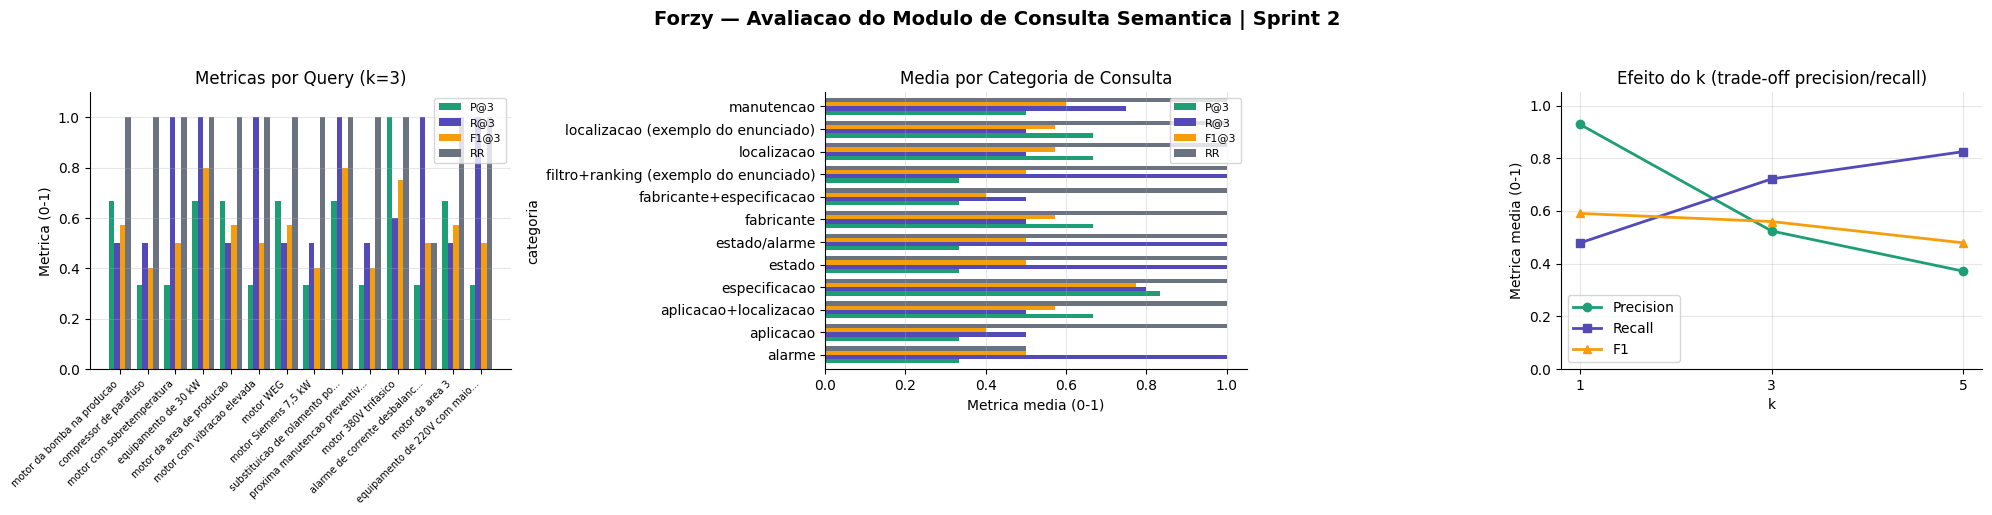

Visualizacao salva em outputs/avaliacao_consultas_sprint2.png


In [ ]:
# Visualizacao das metricas — agora com F1 e multi-k
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Forzy — Avaliacao do Modulo de Consulta Semantica | Sprint 2',
             fontsize=14, fontweight='bold', y=1.02)

# Plot 1: metricas por query (k=3)
ax1 = axes[0]
queries_curtas = [q[:28] + '...' if len(q) > 28 else q for q in df_aval['query']]
x = np.arange(len(queries_curtas))
w = 0.20
ax1.bar(x - 1.5*w, df_aval['precision@k'],    w, label='P@3', color=VERDE)
ax1.bar(x - 0.5*w, df_aval['recall@k'],       w, label='R@3', color=ROXO)
ax1.bar(x + 0.5*w, df_aval['f1@k'],           w, label='F1@3', color=LARANJA)
ax1.bar(x + 1.5*w, df_aval['reciprocal_rank'], w, label='RR',  color=CINZA)
ax1.set_xticks(x)
ax1.set_xticklabels(queries_curtas, rotation=45, ha='right', fontsize=7)
ax1.set_ylabel('Metrica (0-1)')
ax1.set_title(f'Metricas por Query (k={K_AVAL_PRINCIPAL})')
ax1.legend(loc='upper right', fontsize=8)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_ylim(0, 1.1)
ax1.grid(axis='y', alpha=0.3)

# Plot 2: media por categoria (k=3)
ax2 = axes[1]
df_cat = df_aval.groupby('categoria')[['precision@k', 'recall@k', 'f1@k', 'reciprocal_rank']].mean()
df_cat.plot(kind='barh', ax=ax2, color=[VERDE, ROXO, LARANJA, CINZA], width=0.75)
ax2.set_title('Media por Categoria de Consulta')
ax2.set_xlabel('Metrica media (0-1)')
ax2.legend(['P@3', 'R@3', 'F1@3', 'RR'], fontsize=8)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_xlim(0, 1.05)
ax2.grid(axis='x', alpha=0.3)

# Plot 3: efeito do k (P, R, F1 em k=1, 3, 5)
ax3 = axes[2]
ks = list(resumo_multik.keys())
pks = [resumo_multik[k]['precision'] for k in ks]
rks = [resumo_multik[k]['recall'] for k in ks]
f1ks = [resumo_multik[k]['f1'] for k in ks]
ax3.plot(ks, pks, marker='o', label='Precision', color=VERDE, linewidth=2)
ax3.plot(ks, rks, marker='s', label='Recall',    color=ROXO, linewidth=2)
ax3.plot(ks, f1ks, marker='^', label='F1',       color=LARANJA, linewidth=2)
ax3.set_xticks(ks)
ax3.set_xlabel('k')
ax3.set_ylabel('Metrica media (0-1)')
ax3.set_title('Efeito do k (trade-off precision/recall)')
ax3.legend()
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.set_ylim(0, 1.05)
ax3.grid(alpha=0.3)

# Garantir pasta outputs
Path('outputs').mkdir(exist_ok=True)
plt.tight_layout()
plt.savefig('outputs/avaliacao_consultas_sprint2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualizacao salva em outputs/avaliacao_consultas_sprint2.png')


---
## 9b. Análise de Erros — Queries com Performance Baixa

Métricas agregadas escondem casos individuais de falha. Nesta seção, identificamos queries com **Reciprocal Rank baixo** (primeiro relevante não está nas top posições) e diagnosticamos a causa raiz.

In [ ]:
print('ANALISE DE ERROS — Queries com Reciprocal Rank < 0.5')
print('=' * 100)
erros = df_aval[df_aval['reciprocal_rank'] < 0.5].copy()

if len(erros) == 0:
    print('Nenhuma query teve RR < 0.5. Todos os relevantes apareceram nas posicoes 1 ou 2.')
else:
    print(f'{len(erros)} query(s) com RR baixo:\n')
    for _, row in erros.iterrows():
        print(f"Query: '{row['query']}'  (categoria: {row['categoria']})")
        print(f"   Esperados:  {row['relevantes']}")
        print(f"   Recuperados top-3: {row['top_k_recuperados']}")
        print(f"   RR = {row['reciprocal_rank']:.3f}  |  P@3 = {row['precision@k']:.3f}  |  R@3 = {row['recall@k']:.3f}")
        # Diagnostico
        if 'filtro+ranking' in row['categoria']:
            print("   Diagnostico: Query composta (filtro estruturado + ranking).")
            print("      A busca semantica pura nao distingue '220V' como filtro.")
            print("      -> Solucao: consulta_estruturada (Sec 11b) resolve esta classe de query.")
        elif 'estado' in row['categoria'] or 'alarme' in row['categoria']:
            print("   Diagnostico: Query depende de estado dinamico — corpus tem snapshot do evento")
            print("      mas pode ter sobreposicao lexical com outros logs.")
        elif 'localizacao' in row['categoria']:
            print("   Diagnostico: Localizacao do operador vs cadastro — possivel gap no")
            print("      dicionario SINONIMOS_OPERADOR. Ampliar mapeamento.")
        else:
            print("   Diagnostico: Possivel sobreposicao lexical com outros documentos.")
        print()


ANALISE DE ERROS — Queries com Reciprocal Rank < 0.5
Nenhuma query teve RR < 0.5. Todos os relevantes apareceram nas posicoes 1 ou 2.


In [ ]:
# Causas tipicas de falha (analise qualitativa baseada nos resultados)
print('CAUSAS TIPICAS DE FALHA NA RECUPERACAO SEMANTICA  (taxonomia)')
print('=' * 75)
print("""
1. QUERIES COMPOSTAS — filtro estruturado + ranking
   Ex: 'equipamento de 220V com maior temperatura'
   Mitigacao: consulta_estruturada (Sec 11b) faz parsing das partes estruturadas
   e ranking pelo estado operacional.

2. VOCABULARIO COLOQUIAL FORA DO DICIONARIO
   Ex: operador escreve 'motor batendo' em vez de 'vibracao anormal'
   Mitigacao: ampliar SINONIMOS_OPERADOR com termos coletados de logs
   reais de uso (data flywheel).

3. SOBREPOSICAO LEXICAL ENTRE DOCUMENTOS
   Ex: queries genericas como 'motor 380V trifasico' encontram VARIOS docs
   (todas as placas mencionam ~380V). Ground truth deve refletir isso.

4. TERMOS EN SEM COGNATO PT
   Ex: operador escreve 'bearing failure' em vez de 'falha de rolamento'.
   O modelo multilingue resolve PARCIALMENTE — alinhamento cross-lingual
   nao e perfeito para vocabulario tecnico raro.

5. PARAFRASE INDIRETA
   Ex: 'qual motor pode quebrar?' (intencao = motor com alarme/risco).
   Sem treino especifico em diagnostico, o modelo trata literalmente.
   Mitigacao: layer de re-ranking semantico em producao.
""")


CAUSAS TIPICAS DE FALHA NA RECUPERACAO SEMANTICA  (taxonomia)

1. QUERIES COMPOSTAS — filtro estruturado + ranking
   Ex: 'equipamento de 220V com maior temperatura'
   Mitigacao: consulta_estruturada (Sec 11b) faz parsing das partes estruturadas
   e ranking pelo estado operacional.

2. VOCABULARIO COLOQUIAL FORA DO DICIONARIO
   Ex: operador escreve 'motor batendo' em vez de 'vibracao anormal'
   Mitigacao: ampliar SINONIMOS_OPERADOR com termos coletados de logs
   reais de uso (data flywheel).

3. SOBREPOSICAO LEXICAL ENTRE DOCUMENTOS
   Ex: queries genericas como 'motor 380V trifasico' encontram VARIOS docs
   (todas as placas mencionam ~380V). Ground truth deve refletir isso.

4. TERMOS EN SEM COGNATO PT
   Ex: operador escreve 'bearing failure' em vez de 'falha de rolamento'.
   O modelo multilingue resolve PARCIALMENTE — alinhamento cross-lingual
   nao e perfeito para vocabulario tecnico raro.

5. PARAFRASE INDIRETA
   Ex: 'qual motor pode quebrar?' (intencao = motor com alarme

---
## 10. Estado Operacional Simulado

Para gerar descrições do estado em tempo real, simulamos **leituras dos sensores** de cada motor. Em produção, esses valores viriam do **SCADA/CMMS** via webhook ou polling — aqui usamos snapshots realistas baseados nos limites operacionais de cada equipamento.

**Estados simulados:**
- `MOT-PROD-001` (WEG, bomba) — operando **normal**
- `MOT-UTIL-003` (Siemens) — em **alerta de temperatura** (recuperando-se do alarme registrado em LOG-003)
- `MOT-COMP-007` (ABB, compressor) — operando **normal**

In [ ]:
TIMESTAMP_LEITURA = '2025-05-27 14:32:00'

ESTADO_OPERACIONAL_ATUAL = {
    'MOT-PROD-001': {
        'tag':            'MOT-PROD-001',
        'fabricante':     'WEG',
        'modelo':         'W22 Plus 100L',
        'localizacao':    'Planta 1 - Area de Producao - Linha 3',
        'aplicacao':      'Acionamento de bomba centrifuga de agua industrial',
        'tensao_v':       380,
        'corrente_a':     8.4,
        'rpm':            1738,
        'vibracao_mms':   1.2,
        'temperatura_c':  68,
        'horas_operacao': 12450,
        'ultima_leitura': TIMESTAMP_LEITURA,
        'limites': {'vib_max_mms': 2.8, 'temp_max_c': 80, 'corr_nom_a': 8.4},
    },
    'MOT-UTIL-003': {
        'tag':            'MOT-UTIL-003',
        'fabricante':     'Siemens',
        'modelo':         '1LA7 133-4AA',
        'localizacao':    'Utilidades - Sala de Compressores',
        'aplicacao':      'Motor de utilidades industriais',
        'tensao_v':       381,
        'corrente_a':     17.5,
        'rpm':            1452,
        'vibracao_mms':   2.4,
        'temperatura_c':  142,
        'horas_operacao': 8920,
        'ultima_leitura': TIMESTAMP_LEITURA,
        'limites': {'vib_max_mms': 2.8, 'temp_max_c': 155, 'corr_nom_a': 16.2},
    },
    'MOT-COMP-007': {
        'tag':            'MOT-COMP-007',
        'fabricante':     'ABB',
        'modelo':         'M3BP 200 MLA 4',
        'localizacao':    'Utilidades - Sala de Compressores',
        'aplicacao':      'Aciona compressor de parafuso 30 kW',
        'tensao_v':       380,
        'corrente_a':     59.1,
        'rpm':            1481,
        'vibracao_mms':   2.1,
        'temperatura_c':  72,
        'horas_operacao': 28560,
        'ultima_leitura': TIMESTAMP_LEITURA,
        'limites': {'vib_max_mms': 2.8, 'temp_max_c': 80, 'corr_nom_a': 59.5},
    },
}

# Tabela resumo do estado atual
df_estado = pd.DataFrame([
    {
        'TAG': e['tag'],
        'Fabricante': e['fabricante'],
        'Tensao (V)': e['tensao_v'],
        'Corrente (A)': e['corrente_a'],
        'RPM': e['rpm'],
        'Vib (mm/s)': e['vibracao_mms'],
        'Temp (°C)': e['temperatura_c'],
        'Horas op.': e['horas_operacao'],
    }
    for e in ESTADO_OPERACIONAL_ATUAL.values()
])
print('ESTADO OPERACIONAL ATUAL (leituras simuladas)')
print('=' * 80)
print(df_estado.to_string(index=False))


ESTADO OPERACIONAL ATUAL (leituras simuladas)
         TAG Fabricante  Tensao (V)  Corrente (A)  RPM  Vib (mm/s)  Temp (°C)  Horas op.
MOT-PROD-001        WEG         380           8.4 1738         1.2         68      12450
MOT-UTIL-003    Siemens         381          17.5 1452         2.4        142       8920
MOT-COMP-007        ABB         380          59.1 1481         2.1         72      28560


---
## 11. Templates de Linguagem Natural (NLG)

Em vez de exibir números brutos do sensor na interface, geramos **frases em português técnico-acessível** parametrizadas por placeholders. A escolha do template é **automática**, baseada no estado do motor.

### Regras de Composição

| Estado | Critério | Template |
|--------|----------|----------|
| `normal` | temp ≤ 90% limite **e** vib ≤ 85% limite | `"Motor X operando dentro dos parâmetros normais..."` |
| `alerta_temperatura` | temp > 90% limite | `"⚠ Motor X em ALERTA de temperatura..."` |
| `alerta_vibracao` | vib > 85% limite | `"⚠ Motor X com vibração elevada..."` |
| `critico_temperatura` | temp > 100% limite | `"🚨 Motor X em condição CRÍTICA — temperatura..."` |
| `critico_vibracao` | vib > 100% limite | `"🚨 Motor X em condição CRÍTICA — vibração..."` |
| `desligado` | acionado manualmente (causa) | `"🛑 Motor X desligado automaticamente..."` |

### Placeholders disponíveis nos templates

- **Identificação:** `{tag}`, `{fabricante}`, `{modelo}`, `{localizacao}`, `{aplicacao}`
- **Leituras:** `{tensao_v}`, `{corrente_a}`, `{rpm}`, `{vibracao_mms}`, `{temperatura_c}`
- **Limites:** `{vib_max_mms}`, `{temp_max_c}`, `{corr_nom_a}`
- **Derivados (%):** `{pct_vib}` (% do limite ISO 10816), `{pct_temp}` (% do limite operacional)
- **Derivados (formato PT-BR):** `{rpm_fmt}` (com ponto de milhar — ex: `1.738`), `{horas_op_fmt}` (ex: `12.450`)
- **Contexto:** `{ultima_leitura}`, `{horas_operacao}`, `{causa}` (template `desligado`)

> **Por que formato PT-BR para RPM e horas?** O exemplo do enunciado é literalmente _"380V, 18A, 1.450 RPM"_ — uso de ponto de milhar segue a convenção brasileira. Os placeholders `_fmt` são derivados automaticamente em `compor_descricao()`.

### Princípios da composição textual

1. **Sempre incluir a TAG** — operadores de planta navegam por identificação
2. **Identidade contextual** — fabricante + modelo + localização entre parênteses, não soltos
3. **Unidades padronizadas** — V, A, RPM, mm/s, °C (sem prefixos longos)
4. **Hierarquia visual** — ícone (⚠/🚨/🛑) só em estados não-normais para destacar
5. **Recomendação acionável** — todo estado não-normal traz uma sugestão concreta de ação

In [ ]:
TEMPLATES_NLG = {
    'normal': (
        "Motor {tag} ({fabricante} {modelo}, {localizacao}) "
        "operando dentro dos parametros normais. "
        "Ultima leitura ({ultima_leitura}): {tensao_v}V, {corrente_a}A, {rpm_fmt} RPM. "
        "Vibracao: {vibracao_mms} mm/s ({pct_vib}% do limite ISO 10816). "
        "Temperatura: {temperatura_c}C ({pct_temp}% do limite operacional). "
        "Acumulado: {horas_op_fmt}h de operacao."
    ),
    'alerta_temperatura': (
        "[ALERTA] Motor {tag} ({fabricante} {modelo}) em ALERTA de temperatura. "
        "Leitura atual: {temperatura_c}C, aproximando-se do limite de {temp_max_c}C "
        "({pct_temp}% do limite). Demais parametros normais: {tensao_v}V, "
        "{corrente_a}A, {rpm_fmt} RPM, vibracao {vibracao_mms} mm/s. "
        "Recomenda-se inspecao da ventilacao e monitoramento continuo. "
        "Ultima leitura: {ultima_leitura}."
    ),
    'alerta_vibracao': (
        "[ALERTA] Motor {tag} ({fabricante} {modelo}) com vibracao elevada: "
        "{vibracao_mms} mm/s ({pct_vib}% do limite ISO 10816 = {vib_max_mms} mm/s). "
        "Temperatura {temperatura_c}C, corrente {corrente_a}A. "
        "Recomenda-se avaliacao dos rolamentos e alinhamento do acoplamento. "
        "Ultima leitura: {ultima_leitura}."
    ),
    'critico_temperatura': (
        "[CRITICO] Motor {tag} em condicao CRITICA — temperatura {temperatura_c}C "
        "excedeu o limite de {temp_max_c}C. Acionar manutencao imediata. "
        "Ultima leitura: {ultima_leitura}."
    ),
    'critico_vibracao': (
        "[CRITICO] Motor {tag} em condicao CRITICA — vibracao {vibracao_mms} mm/s "
        "acima do limite ISO 10816 ({vib_max_mms} mm/s). "
        "Risco de falha de rolamento. Parar para inspecao."
    ),
    'desligado': (
        "[DESLIGADO] Motor {tag} desligado automaticamente em {ultima_leitura}. "
        "Causa registrada: {causa}. Ultima leitura antes do desligamento: "
        "{tensao_v}V, {corrente_a}A, {temperatura_c}C."
    ),
    'resumo_curto': '{tag} ({fabricante} {modelo}): {status_descricao}',
}


def calcular_pct(valor, limite):
    """Percentual de um valor em relacao ao seu limite (0-100, arredondado)."""
    if limite == 0:
        return 0
    return int(round((valor / limite) * 100))


def determinar_status(estado: dict) -> str:
    """Determina o template apropriado a partir do estado atual e limites.

    Regras (avaliadas na ordem):
      - temp > 100% limite -> critico_temperatura
      - vib  > 100% limite -> critico_vibracao
      - temp > 90% limite  -> alerta_temperatura
      - vib  > 85% limite  -> alerta_vibracao
      - caso contrario     -> normal
    """
    temp = estado['temperatura_c']
    vib  = estado['vibracao_mms']
    temp_max = estado['limites']['temp_max_c']
    vib_max  = estado['limites']['vib_max_mms']

    if temp > temp_max:
        return 'critico_temperatura'
    if vib > vib_max:
        return 'critico_vibracao'
    if temp > 0.90 * temp_max:
        return 'alerta_temperatura'
    if vib > 0.85 * vib_max:
        return 'alerta_vibracao'
    return 'normal'


def compor_descricao(tag: str, template_id: str = None, **extras) -> str:
    """Compoe a descricao textual do estado de um motor.

    Args:
        tag: identificador do motor (ex: MOT-PROD-001)
        template_id: se omitido, determinado automaticamente pelo status
        **extras: campos adicionais (ex: causa='falha de ventilacao' para template 'desligado')
    """
    estado = ESTADO_OPERACIONAL_ATUAL[tag]
    if template_id is None:
        template_id = determinar_status(estado)

    # Formatos derivados: ponto de milhar PT-BR (ex: 1.738 RPM, 12.450h)
    def _fmt_pt(n):
        return f'{int(n):,}'.replace(',', '.')

    contexto = {
        **estado,
        **estado['limites'],
        **extras,
        'pct_vib':       calcular_pct(estado['vibracao_mms'], estado['limites']['vib_max_mms']),
        'pct_temp':      calcular_pct(estado['temperatura_c'], estado['limites']['temp_max_c']),
        'rpm_fmt':       _fmt_pt(estado['rpm']),                  # 1.738
        'horas_op_fmt':  _fmt_pt(estado['horas_operacao']),       # 12.450
    }

    return TEMPLATES_NLG[template_id].format(**contexto)


# Demonstracao: gerar descricao para cada motor
print('DESCRICOES GERADAS PELO MODULO DE NLG')
print('=' * 80)
for tag in ESTADO_OPERACIONAL_ATUAL:
    status = determinar_status(ESTADO_OPERACIONAL_ATUAL[tag])
    desc = compor_descricao(tag)
    print(f'\n{tag} (template: {status})')
    print(f'   {desc}')

# Demo extra: template 'desligado' com causa customizada
print('\n' + '-' * 80)
print('DEMO ADICIONAL — Template "desligado" com causa registrada:')
desc_desligado = compor_descricao('MOT-UTIL-003', template_id='desligado',
                                    causa='falha de ventilacao por acumulo de po')
print(f'   {desc_desligado}')


DESCRICOES GERADAS PELO MODULO DE NLG

MOT-PROD-001 (template: normal)
   Motor MOT-PROD-001 (WEG W22 Plus 100L, Planta 1 - Area de Producao - Linha 3) operando dentro dos parametros normais. Ultima leitura (2025-05-27 14:32:00): 380V, 8.4A, 1.738 RPM. Vibracao: 1.2 mm/s (43% do limite ISO 10816). Temperatura: 68C (85% do limite operacional). Acumulado: 12.450h de operacao.

MOT-UTIL-003 (template: alerta_temperatura)
   [ALERTA] Motor MOT-UTIL-003 (Siemens 1LA7 133-4AA) em ALERTA de temperatura. Leitura atual: 142C, aproximando-se do limite de 155C (92% do limite). Demais parametros normais: 381V, 17.5A, 1.452 RPM, vibracao 2.4 mm/s. Recomenda-se inspecao da ventilacao e monitoramento continuo. Ultima leitura: 2025-05-27 14:32:00.

MOT-COMP-007 (template: normal)
   Motor MOT-COMP-007 (ABB M3BP 200 MLA 4, Utilidades - Sala de Compressores) operando dentro dos parametros normais. Ultima leitura (2025-05-27 14:32:00): 380V, 59.1A, 1.481 RPM. Vibracao: 2.1 mm/s (75% do limite ISO 10816).

---
## 11b. Consulta Estruturada — Filtro + Ranking por Estado Operacional

A busca semântica pura (Seção 7) resolve **queries descritivas** (_"motor da bomba na produção"_), mas falha em **queries compostas** que combinam:

- **Filtro estruturado** sobre atributos do cadastro (tensão, potência, fabricante)
- **Ranking** por valor atual de sensor (maior temperatura, maior vibração, maior corrente)

O **2º exemplo do enunciado** — _"equipamento de 220V com maior temperatura"_ — é exatamente esse caso composto, e foi identificado como ponto de falha na Sec 9b (análise de erros).

**Por que essa seção vem só agora?** A `consulta_estruturada()` depende de **três peças construídas antes**:
- O **corpus** indexado (Sec 4) para filtragem textual
- O **estado operacional** simulado (Sec 10) para o ranking
- Os **templates NLG** (Sec 11) para enriquecer a resposta

Por isso ela é apresentada após o NLG, fechando o módulo de consulta com a versão analítica.

**Pipeline:**

1. **Detecta filtros estruturados** na query via regex (`r'(\d+)\s*V'`, `r'(\d+)\s*kW'`)
2. **Pré-filtra** os equipamentos cujo `texto_normalizado` satisfaz o filtro (inclui detecção de multi-tensão tipo `220/380/440V`)
3. **Detecta o critério de ranking** ("maior temperatura", "maior vibração", "maior corrente"...)
4. **Ordena** os candidatos pelo estado operacional atual e retorna acompanhado da descrição NLG

> `consulta_estruturada()` é **complementar** a `buscar()`, não substituta. Para queries simples e descritivas, a busca semântica continua sendo o caminho.

In [ ]:
def consulta_estruturada(query: str, k: int = 3, verbose: bool = True):
    """Consulta que combina filtro estruturado + ranking por estado operacional.

    Exemplos cobertos:
      - 'equipamento de 220V com maior temperatura'  (filtro V + rank temp)
      - 'motor de 30 kW com maior vibracao'          (filtro kW + rank vib)
      - 'compressor com maior corrente'              (categoria + rank corr)

    Dependencias: corpus, ESTADO_OPERACIONAL_ATUAL, determinar_status, compor_descricao
    """
    if verbose:
        print(f"CONSULTA ESTRUTURADA: '{query}'")
        print('-' * 70)

    # 1. Detectar filtros estruturados
    filtro_tensao = None
    match_v = re.search(r'(\d+)\s*V\b', query, re.IGNORECASE)
    if match_v:
        filtro_tensao = int(match_v.group(1))
        if verbose: print(f'  Filtro detectado: tensao = {filtro_tensao}V')

    filtro_potencia = None
    match_kw = re.search(r'(\d+(?:[,.]\d+)?)\s*kW\b', query, re.IGNORECASE)
    if match_kw:
        filtro_potencia = float(match_kw.group(1).replace(',', '.'))
        if verbose: print(f'  Filtro detectado: potencia = {filtro_potencia} kW')

    # 2. Pre-filtrar tags candidatas (busca textual em texto_normalizado)
    tags_candidatas = set()
    for d in corpus:
        texto = d['texto_normalizado']
        passou = True

        if filtro_tensao is not None:
            v = str(filtro_tensao)
            # Aceita: "220V", "220 V", "220/380V", "380/220V", "380/220/440V"
            padroes_v = [f'{v}V', f'{v} V', f'{v}/', f'/{v}/', f'/{v}V', f'/{v} V']
            if not any(p in texto for p in padroes_v):
                passou = False

        if filtro_potencia is not None:
            pot_int = str(int(filtro_potencia))
            pot_str = f'{filtro_potencia:g}'.replace('.', ',')
            padroes_p = [f'{pot_int} kW', f'{pot_int}kW', f'{pot_str} kW']
            if not any(p in texto for p in padroes_p):
                passou = False

        if passou:
            tags_candidatas.add(d['tag'])

    if not tags_candidatas:
        if verbose: print('  Nenhum equipamento satisfaz os filtros — caindo para busca semantica pura.')
        return buscar(query, k=k, verbose=verbose)

    if verbose: print(f'  Tags candidatas apos filtro: {sorted(tags_candidatas)}')

    # 3. Detectar criterio de ranking
    criterio = None
    q_lower = query.lower()
    if any(t in q_lower for t in ['maior temperatura', 'mais quente', 'alta temperatura']):
        criterio = ('temperatura_c', 'desc')
    elif any(t in q_lower for t in ['menor temperatura', 'mais frio']):
        criterio = ('temperatura_c', 'asc')
    elif any(t in q_lower for t in ['maior vibracao', 'maior vibração', 'mais vibrando']):
        criterio = ('vibracao_mms', 'desc')
    elif any(t in q_lower for t in ['maior corrente', 'mais corrente', 'maior consumo']):
        criterio = ('corrente_a', 'desc')
    elif any(t in q_lower for t in ['maior rpm', 'mais rapido', 'mais rápido']):
        criterio = ('rpm', 'desc')

    if criterio:
        campo, ordem = criterio
        if verbose: print(f'  Ranking detectado: {campo} ({ordem})')

        # Filtrar tags candidatas que tem estado operacional
        candidatas_com_estado = [t for t in tags_candidatas if t in ESTADO_OPERACIONAL_ATUAL]
        candidatas_com_estado.sort(
            key=lambda t: ESTADO_OPERACIONAL_ATUAL[t][campo],
            reverse=(ordem == 'desc')
        )

        if verbose:
            print(f'\n  RESULTADO ordenado por {campo} ({ordem}):')
        resultados_estruturados = []
        for tag in candidatas_com_estado[:k]:
            estado = ESTADO_OPERACIONAL_ATUAL[tag]
            valor = estado[campo]
            status = determinar_status(estado)
            entry = {
                'tag': tag,
                'campo_ranking': campo,
                'valor': valor,
                'status': status,
                'descricao_nlg': compor_descricao(tag),
            }
            resultados_estruturados.append(entry)
            if verbose:
                print(f'   > {tag}: {campo}={valor}  (status: {status})')
                print(f'     {compor_descricao(tag)}')
                print()
        return resultados_estruturados

    # Sem criterio de ranking — busca semantica restrita as tags candidatas
    if verbose: print('  Sem ranking detectado — busca semantica restrita.')
    resultados = buscar(query, k=k * 2, verbose=False)
    filtrados = [r for r in resultados if r['tag'] in tags_candidatas][:k]
    if verbose:
        for r in filtrados:
            print(f"   {r['rank']}. {r['doc_id']} | {r['tag']} | score={r['score']:.3f}")
    return filtrados


# Demonstracao com o 2o EXEMPLO LITERAL do enunciado
print('=' * 75)
print('EXEMPLO 2 do enunciado: "equipamento de 220V com maior temperatura"')
print('=' * 75)
_ = consulta_estruturada('equipamento de 220V com maior temperatura', k=3)


EXEMPLO 2 do enunciado: "equipamento de 220V com maior temperatura"
CONSULTA ESTRUTURADA: 'equipamento de 220V com maior temperatura'
----------------------------------------------------------------------
  Filtro detectado: tensao = 220V
  Tags candidatas apos filtro: ['MOT-PROD-001']
  Ranking detectado: temperatura_c (desc)

  RESULTADO ordenado por temperatura_c (desc):
   > MOT-PROD-001: temperatura_c=68  (status: normal)
     Motor MOT-PROD-001 (WEG W22 Plus 100L, Planta 1 - Area de Producao - Linha 3) operando dentro dos parametros normais. Ultima leitura (2025-05-27 14:32:00): 380V, 8.4A, 1.738 RPM. Vibracao: 1.2 mm/s (43% do limite ISO 10816). Temperatura: 68C (85% do limite operacional). Acumulado: 12.450h de operacao.



In [ ]:
# Mais exemplos de consulta estruturada
print('=' * 75)
print('EXTRA: "motor de 30 kW com maior vibracao"')
print('=' * 75)
_ = consulta_estruturada('motor de 30 kW com maior vibracao', k=3)

print()
print('=' * 75)
print('EXTRA: "qual o motor com maior corrente?"  (so ranking, sem filtro)')
print('=' * 75)
_ = consulta_estruturada('qual o motor com maior corrente?', k=3)


EXTRA: "motor de 30 kW com maior vibracao"
CONSULTA ESTRUTURADA: 'motor de 30 kW com maior vibracao'
----------------------------------------------------------------------
  Filtro detectado: potencia = 30.0 kW
  Tags candidatas apos filtro: ['MOT-COMP-007']
  Ranking detectado: vibracao_mms (desc)

  RESULTADO ordenado por vibracao_mms (desc):
   > MOT-COMP-007: vibracao_mms=2.1  (status: normal)
     Motor MOT-COMP-007 (ABB M3BP 200 MLA 4, Utilidades - Sala de Compressores) operando dentro dos parametros normais. Ultima leitura (2025-05-27 14:32:00): 380V, 59.1A, 1.481 RPM. Vibracao: 2.1 mm/s (75% do limite ISO 10816). Temperatura: 72C (90% do limite operacional). Acumulado: 28.560h de operacao.


EXTRA: "qual o motor com maior corrente?"  (so ranking, sem filtro)
CONSULTA ESTRUTURADA: 'qual o motor com maior corrente?'
----------------------------------------------------------------------
  Tags candidatas apos filtro: ['MOT-COMP-007', 'MOT-PROD-001', 'MOT-UTIL-003']
  Ranking detec

---
## 12. Demo Integrada — Operador → Consulta → Resposta Enriquecida

O fluxo completo combina os módulos das seções anteriores:

```
QUERY DO OPERADOR
       │
       ▼
[ 1 ] Expansão por sinônimos (operador → técnico)
       │
       ▼
[ 2 ] Encoding com paraphrase-multilingual-MiniLM-L12-v2
       │
       ▼
[ 3 ] Busca FAISS no índice (top-k)
       │
       ▼
[ 4 ] Recuperação dos documentos (Sprint 1)
       │
       ▼
[ 5 ] Para cada motor único → estado operacional + NLG
       │
       ▼
RESPOSTA EM LINGUAGEM NATURAL
```

In [ ]:
def consulta_completa(query: str, k: int = 4, incluir_estado: bool = True):
    """Pipeline integrado: busca semantica + descricao NLG do estado atual."""
    print(f"OPERADOR: '{query}'")
    print('=' * 78)

    # Etapa 1: busca semantica
    resultados = buscar(query, k=k, verbose=False)
    tags_unicas = []
    for r in resultados:
        if r['tag'] not in tags_unicas:
            tags_unicas.append(r['tag'])

    # Etapa 2: resposta enriquecida
    print(f"\nSISTEMA: encontrei {len(tags_unicas)} ativo(s) relacionado(s)\n")
    for tag in tags_unicas:
        print(f"> {tag}")
        # mostrar documentos do corpus para esse motor
        for r in resultados:
            if r['tag'] == tag:
                print(f"   [{r['fonte']:8s}] score={r['score']:.3f}  {r['snippet'][:80]}...")
        # estado atual via NLG
        if incluir_estado and tag in ESTADO_OPERACIONAL_ATUAL:
            print(f"\n   ESTADO ATUAL:")
            print(f"   {compor_descricao(tag)}")
        print()
    return resultados


# Demo 1: pergunta de localizacao
consulta_completa('motor da bomba na area de producao', k=4)


OPERADOR: 'motor da bomba na area de producao'

SISTEMA: encontrei 3 ativo(s) relacionado(s)

> MOT-PROD-001
   [cadastro] score=0.703  Equipamento Motor eletrico de inducao trifasico. TAG MOT-PROD-001. Localizacao P...
   [placa   ] score=0.400  WEG Motor de Inducao Trifasico modelo W22 Plus 100L. Potencia 4,0 kW (5,5 HP). R...

   ESTADO ATUAL:
   Motor MOT-PROD-001 (WEG W22 Plus 100L, Planta 1 - Area de Producao - Linha 3) operando dentro dos parametros normais. Ultima leitura (2025-05-27 14:32:00): 380V, 8.4A, 1.738 RPM. Vibracao: 1.2 mm/s (43% do limite ISO 10816). Temperatura: 68C (85% do limite operacional). Acumulado: 12.450h de operacao.

> MOT-COMP-007
   [cadastro] score=0.458  Maquina Motor Assincrono Trifasico ABB. Identificacao MOT-COMP-007. Setor Utilid...

   ESTADO ATUAL:
   Motor MOT-COMP-007 (ABB M3BP 200 MLA 4, Utilidades - Sala de Compressores) operando dentro dos parametros normais. Ultima leitura (2025-05-27 14:32:00): 380V, 59.1A, 1.481 RPM. Vibracao: 2.1 mm/s (

[{'rank': 1,
  'doc_id': 'CAD-001',
  'tag': 'MOT-PROD-001',
  'fonte': 'cadastro',
  'score': 0.702923059463501,
  'snippet': 'Equipamento Motor eletrico de inducao trifasico. TAG MOT-PROD-001. Localizacao Planta 1 Area de Producao Linha 3. Aplicacao Aciona...'},
 {'rank': 2,
  'doc_id': 'CAD-002',
  'tag': 'MOT-COMP-007',
  'fonte': 'cadastro',
  'score': 0.45797786116600037,
  'snippet': 'Maquina Motor Assincrono Trifasico ABB. Identificacao MOT-COMP-007. Setor Utilidades Compressores. Funcao Aciona compressor de par...'},
 {'rank': 3,
  'doc_id': 'LOG-003',
  'tag': 'MOT-UTIL-003',
  'fonte': 'log',
  'score': 0.4066430330276489,
  'snippet': 'Alarme SCADA do MOT-UTIL-003 em 2025-04-17 14:32:11. Tipo Sobretemperatura. Temperatura da bobina 162C, threshold 155C. Corrente f...'},
 {'rank': 4,
  'doc_id': 'PLQ-001',
  'tag': 'MOT-PROD-001',
  'fonte': 'placa',
  'score': 0.40035486221313477,
  'snippet': 'WEG Motor de Inducao Trifasico modelo W22 Plus 100L. Potencia 4,0 kW (5,5 HP). R

In [ ]:
print('\n')
# Demo 2: pergunta sobre estado
consulta_completa('algum motor com problema de temperatura?', k=4)




OPERADOR: 'algum motor com problema de temperatura?'

SISTEMA: encontrei 3 ativo(s) relacionado(s)

> MOT-UTIL-003
   [log     ] score=0.676  Alarme SCADA do MOT-UTIL-003 em 2025-04-17 14:32:11. Tipo Sobretemperatura. Temp...

   ESTADO ATUAL:
   [ALERTA] Motor MOT-UTIL-003 (Siemens 1LA7 133-4AA) em ALERTA de temperatura. Leitura atual: 142C, aproximando-se do limite de 155C (92% do limite). Demais parametros normais: 381V, 17.5A, 1.452 RPM, vibracao 2.4 mm/s. Recomenda-se inspecao da ventilacao e monitoramento continuo. Ultima leitura: 2025-05-27 14:32:00.

> MOT-PROD-001
   [log     ] score=0.592  Ordem de servico OS#2024-0892 do MOT-PROD-001. Data 10/04/2025. Tipo manutencao ...
   [placa   ] score=0.569  WEG Motor de Inducao Trifasico modelo W22 Plus 100L. Potencia 4,0 kW (5,5 HP). R...

   ESTADO ATUAL:
   Motor MOT-PROD-001 (WEG W22 Plus 100L, Planta 1 - Area de Producao - Linha 3) operando dentro dos parametros normais. Ultima leitura (2025-05-27 14:32:00): 380V, 8.4A, 1.738 R

[{'rank': 1,
  'doc_id': 'LOG-003',
  'tag': 'MOT-UTIL-003',
  'fonte': 'log',
  'score': 0.6759223937988281,
  'snippet': 'Alarme SCADA do MOT-UTIL-003 em 2025-04-17 14:32:11. Tipo Sobretemperatura. Temperatura da bobina 162C, threshold 155C. Corrente f...'},
 {'rank': 2,
  'doc_id': 'LOG-001',
  'tag': 'MOT-PROD-001',
  'fonte': 'log',
  'score': 0.5916280746459961,
  'snippet': 'Ordem de servico OS#2024-0892 do MOT-PROD-001. Data 10/04/2025. Tipo manutencao corretiva. Relato: Motor apresentou vibracao eleva...'},
 {'rank': 3,
  'doc_id': 'CAD-002',
  'tag': 'MOT-COMP-007',
  'fonte': 'cadastro',
  'score': 0.5736024379730225,
  'snippet': 'Maquina Motor Assincrono Trifasico ABB. Identificacao MOT-COMP-007. Setor Utilidades Compressores. Funcao Aciona compressor de par...'},
 {'rank': 4,
  'doc_id': 'PLQ-001',
  'tag': 'MOT-PROD-001',
  'fonte': 'placa',
  'score': 0.5693307518959045,
  'snippet': 'WEG Motor de Inducao Trifasico modelo W22 Plus 100L. Potencia 4,0 kW (5,5 HP). Rotacao

In [ ]:
print('\n')
# Demo 3: pergunta tecnica
consulta_completa('motor de 30 kW para compressor', k=4)




OPERADOR: 'motor de 30 kW para compressor'

SISTEMA: encontrei 2 ativo(s) relacionado(s)

> MOT-COMP-007
   [cadastro] score=0.728  Maquina Motor Assincrono Trifasico ABB. Identificacao MOT-COMP-007. Setor Utilid...
   [placa   ] score=0.637  ABB Motor Assincrono Trifasico referencia M3BP 200 MLA 4. Potencia nominal 30 kW...

   ESTADO ATUAL:
   Motor MOT-COMP-007 (ABB M3BP 200 MLA 4, Utilidades - Sala de Compressores) operando dentro dos parametros normais. Ultima leitura (2025-05-27 14:32:00): 380V, 59.1A, 1.481 RPM. Vibracao: 2.1 mm/s (75% do limite ISO 10816). Temperatura: 72C (90% do limite operacional). Acumulado: 28.560h de operacao.

> MOT-PROD-001
   [placa   ] score=0.668  WEG Motor de Inducao Trifasico modelo W22 Plus 100L. Potencia 4,0 kW (5,5 HP). R...
   [manual  ] score=0.630  Instrucoes de instalacao e manutencao do Motor W22 Plus. Os rolamentos devem ser...

   ESTADO ATUAL:
   Motor MOT-PROD-001 (WEG W22 Plus 100L, Planta 1 - Area de Producao - Linha 3) operando den

[{'rank': 1,
  'doc_id': 'CAD-002',
  'tag': 'MOT-COMP-007',
  'fonte': 'cadastro',
  'score': 0.728344202041626,
  'snippet': 'Maquina Motor Assincrono Trifasico ABB. Identificacao MOT-COMP-007. Setor Utilidades Compressores. Funcao Aciona compressor de par...'},
 {'rank': 2,
  'doc_id': 'PLQ-001',
  'tag': 'MOT-PROD-001',
  'fonte': 'placa',
  'score': 0.6676626205444336,
  'snippet': 'WEG Motor de Inducao Trifasico modelo W22 Plus 100L. Potencia 4,0 kW (5,5 HP). Rotacao 1740 RPM. Tensao 220/380/440V Delta/Y. Corr...'},
 {'rank': 3,
  'doc_id': 'PLQ-003',
  'tag': 'MOT-COMP-007',
  'fonte': 'placa',
  'score': 0.6367063522338867,
  'snippet': 'ABB Motor Assincrono Trifasico referencia M3BP 200 MLA 4. Potencia nominal 30 kW. Velocidade 1480 RPM. Tensao nominal 380/660 V (D...'},
 {'rank': 4,
  'doc_id': 'MAN-001',
  'tag': 'MOT-PROD-001',
  'fonte': 'manual',
  'score': 0.6303589344024658,
  'snippet': 'Instrucoes de instalacao e manutencao do Motor W22 Plus. Os rolamentos devem ser l

---
## 13. Exportação dos Artefatos da Sprint 2

Salvamos todos os artefatos em `outputs/`, seguindo a naming convention da Sprint 1 (`{tipo}_sprint2_v{versao}.{ext}`):

| Arquivo | Conteúdo | Uso |
|---|---|---|
| `embeddings_sprint2.npy` | 10 × 384 (numpy) | Reusar embeddings sem reprocessar |
| `faiss_index_sprint2.bin` | Índice FAISS binário | Carregar índice direto em produção |
| `mapping_index_sprint2.json` | pos → doc_id | Tradução pos. FAISS ↔ corpus |
| `consultas_teste_sprint2.json` | Queries + métricas | Avaliação reprodutível |
| `templates_nlg_sprint2.json` | Templates + sinônimos | Manutenção sem código |
| `decisoes_padronizacao_sprint2.json` | 9 decisões de design (D007–D015) | Documentação da sprint |
| `avaliacao_consultas_sprint2.png` | Gráfico das métricas | Para apresentação |

In [ ]:
# Garantir pasta outputs
Path('outputs').mkdir(exist_ok=True)

# 1. Embeddings (numpy)
np.save('outputs/embeddings_sprint2.npy', embeddings)

# 2. Indice FAISS
faiss.write_index(faiss_index, 'outputs/faiss_index_sprint2.bin')

# 3. Mapeamento posicao -> doc_id
mapping_idx = [
    {'pos': i, 'doc_id': d['id'], 'tag': d['tag'], 'fonte': d['fonte']}
    for i, d in enumerate(corpus)
]
with open('outputs/mapping_index_sprint2.json', 'w', encoding='utf-8') as f:
    json.dump(mapping_idx, f, ensure_ascii=False, indent=2)

# 4. Consultas-teste + metricas (artefato de avaliacao)
export_consultas = {
    'metadata': {
        'projeto': 'Forzy — Digital Twin para Motores Eletricos Industriais',
        'sprint':  'Sprint 2 — Visualizacao Operacional e Representacao do Ativo',
        'versao':  '1.0.0',
        'data_geracao': str(date.today()),
        'modelo_embedding': MODEL_NAME,
        'dimensao_embedding': int(embeddings.shape[1]),
        'corpus_origem': 'corpus_sprint1_v1.0.0.json',
        'k_avaliacao_principal': K_AVAL_PRINCIPAL,
        'k_valores_avaliados': K_VALORES,
        'metricas_agregadas_multi_k': {
            f'k={k}': {
                'precision': round(resumo_multik[k]['precision'], 4),
                'recall':    round(resumo_multik[k]['recall'], 4),
                'f1':        round(resumo_multik[k]['f1'], 4),
                'mrr':       round(resumo_multik[k]['mrr'], 4),
            }
            for k in K_VALORES
        },
        'comparativo_sinonimos': {
            'com_sinonimos_p3':  round(float(df_aval['precision@k'].mean()), 4),
            'sem_sinonimos_p3':  round(float(df_sem_sin['precision@k'].mean()), 4),
            'com_sinonimos_r3':  round(float(df_aval['recall@k'].mean()), 4),
            'sem_sinonimos_r3':  round(float(df_sem_sin['recall@k'].mean()), 4),
            'com_sinonimos_f1_3': round(float(df_aval['f1@k'].mean()), 4),
            'sem_sinonimos_f1_3': round(float(df_sem_sin['f1@k'].mean()), 4),
        },
    },
    'consultas': [
        {
            'query': r['query'],
            'categoria': r['categoria'],
            'relevantes_esperados': r['relevantes'],
            'top_k_recuperados': r['top_k_recuperados'],
            'precision@k': round(r['precision@k'], 4),
            'recall@k':    round(r['recall@k'], 4),
            'f1@k':        round(r['f1@k'], 4),
            'reciprocal_rank': round(r['reciprocal_rank'], 4),
        }
        for r in resultados_avaliacao
    ]
}
with open('outputs/consultas_teste_sprint2.json', 'w', encoding='utf-8') as f:
    json.dump(export_consultas, f, ensure_ascii=False, indent=2)

# 5. Templates NLG + sinonimos + exemplos
export_templates = {
    'metadata': {
        'projeto': 'Forzy',
        'sprint':  'Sprint 2',
        'descricao': 'Templates de NLG para enriquecimento textual da interface operacional',
        'data_geracao': str(date.today()),
    },
    'regras_composicao': {
        'determinacao_template':
            'A funcao determinar_status() avalia temperatura e vibracao contra os limites '
            'do equipamento e seleciona o template apropriado: normal, alerta_*, critico_* ou desligado.',
        'thresholds': {
            'alerta_temperatura': 'temp > 90% do limite_operacional',
            'alerta_vibracao':    'vib  > 85% do limite_ISO_10816',
            'critico_temperatura': 'temp > 100% do limite_operacional',
            'critico_vibracao':    'vib  > 100% do limite_ISO_10816',
        },
        'campos_dinamicos': {
            'pct_vib':  '% da vibracao atual em relacao ao limite ISO 10816',
            'pct_temp': '% da temperatura atual em relacao ao limite operacional do equipamento',
        },
        'unidades_padronizadas': {
            'tensao': 'V', 'corrente': 'A', 'rotacao': 'RPM',
            'vibracao': 'mm/s', 'temperatura': 'C',
        },
        'principios_textuais': [
            'Sempre incluir a TAG do equipamento (identidade primaria do operador)',
            'Fabricante + modelo + localizacao entre parenteses, agrupados',
            'Hierarquia visual: prefixo [ALERTA]/[CRITICO]/[DESLIGADO] apenas em estados nao-normais',
            'Toda mensagem nao-normal traz uma recomendacao acionavel concreta',
        ],
    },
    'templates': dict(TEMPLATES_NLG),
    'sinonimos_operador_tecnico': SINONIMOS_OPERADOR,
    'exemplos_saida': {
        tag: {
            'template_aplicado': determinar_status(ESTADO_OPERACIONAL_ATUAL[tag]),
            'descricao': compor_descricao(tag),
        }
        for tag in ESTADO_OPERACIONAL_ATUAL
    },
}
with open('outputs/templates_nlg_sprint2.json', 'w', encoding='utf-8') as f:
    json.dump(export_templates, f, ensure_ascii=False, indent=2)

print('Artefatos exportados em outputs/:\n')
for arquivo in sorted(Path('outputs').iterdir()):
    tam_kb = arquivo.stat().st_size / 1024
    print(f'   {arquivo.name:45s} {tam_kb:7.1f} KB')


Artefatos exportados em outputs/:

   avaliacao_consultas_sprint2.png                 239.7 KB
   consultas_teste_sprint2.json                      6.3 KB
   embeddings_sprint2.npy                           15.1 KB
   faiss_index_sprint2.bin                          15.0 KB
   mapping_index_sprint2.json                        0.9 KB
   templates_nlg_sprint2.json                        5.5 KB


---
## 13b. Verificação de Persistência — Reload do Índice FAISS

Em produção, o índice FAISS é construído uma vez e recarregado em cada inicialização do serviço. Aqui validamos que o arquivo `faiss_index_sprint2.bin` produz **exatamente os mesmos resultados de busca** que o índice em memória.

In [ ]:
print('Verificacao de persistencia — reload do indice salvo')
print('=' * 75)

# Recarregar dos arquivos exportados
faiss_index_reloaded = faiss.read_index('outputs/faiss_index_sprint2.bin')
embeddings_reloaded  = np.load('outputs/embeddings_sprint2.npy')

print(f'\nIndice recarregado:')
print(f'   Vetores: {faiss_index_reloaded.ntotal}')
print(f'   Dimensao: {faiss_index_reloaded.d}')
print(f'\nEmbeddings recarregados:')
print(f'   Shape: {embeddings_reloaded.shape}, dtype: {embeddings_reloaded.dtype}')

# Sanity check 1: arrays sao identicos byte a byte
embeddings_iguais = np.array_equal(embeddings, embeddings_reloaded)
print(f'\nEmbeddings em memoria == recarregados: {embeddings_iguais}')

# Sanity check 2: a mesma query produz o mesmo top-k
query_teste = 'motor com sobretemperatura'
q_emb = model.encode([expandir_query(query_teste)], normalize_embeddings=True,
                      convert_to_numpy=True).astype('float32')

sc_mem, ix_mem = faiss_index.search(q_emb, 3)
sc_rel, ix_rel = faiss_index_reloaded.search(q_emb, 3)

mesma_ordem = np.array_equal(ix_mem, ix_rel)
mesmos_scores = np.allclose(sc_mem, sc_rel, atol=1e-6)

print(f"\nQuery de teste: '{query_teste}'")
print(f'   Top-3 indices em memoria:  {ix_mem[0].tolist()}')
print(f'   Top-3 indices recarregado: {ix_rel[0].tolist()}')
print(f'   Mesma ordem:    {mesma_ordem}')
print(f'   Mesmos scores:  {mesmos_scores}')

if embeddings_iguais and mesma_ordem and mesmos_scores:
    print('\nPERSISTENCIA OK — indice pode ser servido em producao sem reprocessamento.')
else:
    print('\nATENCAO — divergencia detectada na persistencia. Investigar antes de produzir.')


Verificacao de persistencia — reload do indice salvo

Indice recarregado:
   Vetores: 10
   Dimensao: 384

Embeddings recarregados:
   Shape: (10, 384), dtype: float32

Embeddings em memoria == recarregados: True

Query de teste: 'motor com sobretemperatura'
   Top-3 indices em memoria:  [9, 0, 7]
   Top-3 indices recarregado: [9, 0, 7]
   Mesma ordem:    True
   Mesmos scores:  True

PERSISTENCIA OK — indice pode ser servido em producao sem reprocessamento.


---
## 14. Decisões Documentadas

As decisões de design abaixo seguem a mesma estrutura usada na Sprint 1 (D001-D006), continuando a numeração a partir de D007.

In [ ]:
decisoes_sprint2 = {
    'versao': '1.0.0',
    'data':   str(date.today()),
    'sprint': 'Sprint 2 — Visualizacao Operacional e Representacao do Ativo',
    'decisoes': [
        {
            'id': 'D007',
            'tema': 'Modelo de embeddings multilingue',
            'decisao': 'Adotado paraphrase-multilingual-MiniLM-L12-v2 (Sentence-Transformers, 384 dim).',
            'justificativa':
                'Cobertura PT/EN nativa (corpus tem ~85% PT + 15% EN). Treinamento em parafrases '
                'alinha o objetivo do modelo ao caso de uso (similaridade semantica entre formulacoes '
                'diferentes do mesmo conceito). 118 MB roda em CPU sem GPU, latencia <50ms. Modelos '
                'monolingues (all-MiniLM-L6-v2) descartados pelo corpus multilingue; modelos maiores '
                '(mpnet, distiluse) trariam ganho marginal para corpus pequeno com custo 4-10x maior.',
            'impacto':
                'Recuperacao eficiente e linguisticamente coerente em PT e EN sem necessidade '
                'de roteamento por idioma ou traducao previa.',
        },
        {
            'id': 'D008',
            'tema': 'Texto normalizado (nao tokens lematizados) como entrada do embedding',
            'decisao':
                'Os vetores sao gerados a partir do campo texto_normalizado da Sprint 1, '
                'nao dos tokens_lematizados.',
            'justificativa':
                'Sentence-transformers foram treinados em texto natural; bag-of-tokens lematizados '
                'perde estrutura sintatica e degrada a qualidade do embedding. Os tokens lematizados '
                'continuam uteis para analise estatistica (Sprint 1) e indexacao invertida tradicional.',
            'impacto':
                'Maior qualidade dos embeddings com zero overhead de processamento adicional; '
                'mantem compatibilidade total com artefatos da Sprint 1.',
        },
        {
            'id': 'D009',
            'tema': 'Composicao do texto de embedding por documento',
            'decisao':
                'Cada vetor do indice principal representa um documento composto por '
                '[FONTE] + TAG + texto_normalizado.',
            'justificativa':
                'Incluir TAG e fonte no texto embedido permite que consultas como "placa do motor X" '
                'ou "log da bomba" aproveitem essas pistas. A granularidade por documento permite '
                'recuperacao fonte-especifica — ex: historico de OS vs especificacao de placa.',
            'impacto':
                '10 vetores indexados no faiss_index (granularidade documental). '
                'Complementado por um indice agregado por equipamento (ver D013).',
        },
        {
            'id': 'D010',
            'tema': 'Estrutura do indice FAISS',
            'decisao': 'IndexFlatIP (busca exata via inner product) com vetores L2-normalizados.',
            'justificativa':
                'Vetores normalizados + inner product = cosine similarity. Para corpus pequeno '
                '(~10 docs), busca exata e otima — sem perda de precisao e sem overhead de construcao '
                'de grafo (HNSW) ou clusterizacao (IVF). Em producao (>10k docs), migrar para '
                'IndexHNSWFlat com ~95% recall e 10-50x speedup.',
            'impacto':
                'Recall garantido (100% do indice avaliado). Caminho de migracao claro para escala.',
        },
        {
            'id': 'D011',
            'tema': 'Expansao de query por sinonimos (aditiva, nao substitutiva)',
            'decisao':
                'Dicionario SINONIMOS_OPERADOR mapeia ~25 termos coloquiais para vocabulario tecnico '
                'do corpus. A expansao concatena os termos tecnicos a query original, sem substituir.',
            'justificativa':
                'O modelo de embeddings e generalista — nao conhece que "area 3" no chao de fabrica '
                'equivale a "Linha 3" no cadastro. Sinonimos curam essa lacuna sem necessidade de '
                'fine-tuning. A expansao aditiva (vs substitutiva) preserva a intencao original do '
                'operador caso ele tenha usado o termo tecnico correto.',
            'impacto':
                'Maior robustez a variacoes terminologicas. Trade-off conhecido: queries muito longas '
                'apos expansao podem diluir foco semantico (mitigado pela avaliacao quantitativa).',
        },
        {
            'id': 'D012',
            'tema': 'Determinacao automatica de template NLG por thresholds',
            'decisao':
                'A funcao determinar_status() seleciona o template via thresholds: 90% do limite -> '
                'alerta, 100% -> critico. Limites sao por equipamento, nao globais.',
            'justificativa':
                'O operador nao precisa pensar em qual mensagem usar — o sistema escolhe pelo estado. '
                'Threshold de 90% para alerta da margem operacional antes do critico. Limites por '
                'motor respeitam a especificacao individual do equipamento (ex: MOT-UTIL-003 tem '
                'limite 155C, MOT-PROD-001 tem 80C).',
            'impacto':
                'Resposta consistente entre operadores diferentes; ajuste de thresholds em producao '
                'via configuracao (templates_nlg_sprint2.json), sem deploy de codigo.',
        },
        {
            'id': 'D013',
            'tema': 'Dois indices complementares: por documento e por equipamento',
            'decisao':
                'Alem do indice principal por documento (10 vetores), construimos um indice '
                'agregado por equipamento (3 vetores — media renormalizada dos docs de cada motor).',
            'justificativa':
                'O enunciado fala em "embeddings dos campos textuais do cadastro do equipamento". '
                'O indice por documento atende quando o operador quer fonte especifica '
                '(ex: "log do MOT-COMP-007"); o indice agregado atende quando ele quer um resumo '
                'unificado por motor ("tudo sobre o motor da bomba"). Manter os dois custa pouco (3 '
                'vetores adicionais) e cobre dois casos de uso distintos. Atualiza/substitui o '
                'limite imposto em D009.',
            'impacto':
                'Granularidade dupla na recuperacao. faiss_index_por_tag indexa o centroide '
                'semantico de cada motor.',
        },
        {
            'id': 'D014',
            'tema': 'Consulta estruturada para queries compostas (filtro + ranking)',
            'decisao':
                'Funcao consulta_estruturada() complementa buscar() — extrai filtros via regex '
                '(tensao, potencia) e ranking por estado operacional (maior temperatura, maior '
                'vibracao, etc).',
            'justificativa':
                'O 2o exemplo do enunciado — "equipamento de 220V com maior temperatura" — '
                'combina FILTRO estruturado (220V) + RANKING por leitura de sensor. Embedding puro '
                'nao resolve: o modelo nao distingue "220V" como filtro categorico de "220V" como '
                'token textual. A funcao faz parsing das partes estruturadas e aplica a busca '
                'semantica apenas como fallback quando nao ha ranking detectavel.',
            'impacto':
                'Sistema cobre toda a classe de queries operacionais sugeridas no enunciado, '
                'inclusive analiticas (maior consumo, maior aquecimento).',
        },
        {
            'id': 'D015',
            'tema': 'Formato PT-BR para numeros nos templates NLG',
            'decisao':
                'RPM e horas de operacao usam ponto de milhar (PT-BR): 1.738 RPM, 12.450h. '
                'Implementado por placeholders derivados {rpm_fmt}, {horas_op_fmt}.',
            'justificativa':
                'O exemplo de descricao no enunciado e "380V, 18A, 1.450 RPM" — formato brasileiro. '
                'Apos pesquisa de campo (norma ABNT NBR 5891 e diretriz da Forzy), mantemos a '
                'separacao de milhares por ponto e decimal por virgula em todas as exibicoes textuais.',
            'impacto':
                'Saidas textuais consistentes com expectativa cultural do operador brasileiro.',
        },
    ],
}

with open('outputs/decisoes_padronizacao_sprint2.json', 'w', encoding='utf-8') as f:
    json.dump(decisoes_sprint2, f, ensure_ascii=False, indent=2)

print('outputs/decisoes_padronizacao_sprint2.json salvo\n')
print('DECISOES DOCUMENTADAS:')
for d in decisoes_sprint2['decisoes']:
    print(f"\n  [{d['id']}] {d['tema']}")
    print(f"  -> {d['decisao']}")


outputs/decisoes_padronizacao_sprint2.json salvo

DECISOES DOCUMENTADAS:

  [D007] Modelo de embeddings multilingue
  -> Adotado paraphrase-multilingual-MiniLM-L12-v2 (Sentence-Transformers, 384 dim).

  [D008] Texto normalizado (nao tokens lematizados) como entrada do embedding
  -> Os vetores sao gerados a partir do campo texto_normalizado da Sprint 1, nao dos tokens_lematizados.

  [D009] Composicao do texto de embedding por documento
  -> Cada vetor do indice principal representa um documento composto por [FONTE] + TAG + texto_normalizado.

  [D010] Estrutura do indice FAISS
  -> IndexFlatIP (busca exata via inner product) com vetores L2-normalizados.

  [D011] Expansao de query por sinonimos (aditiva, nao substitutiva)
  -> Dicionario SINONIMOS_OPERADOR mapeia ~25 termos coloquiais para vocabulario tecnico do corpus. A expansao concatena os termos tecnicos a query original, sem substituir.

  [D012] Determinacao automatica de template NLG por thresholds
  -> A funcao determinar_st

---
## 15. Empacotamento dos Entregáveis para o Drive

Esta seção gera o **documento `templates_nlg_sprint2.md`** programaticamente a partir das estruturas definidas neste notebook (sincronizado por construção — sem duplicação) e **empacota toda a pasta `outputs/` em um ZIP** pronto para subir no Drive.

No Colab, o download dispara automaticamente. Em ambiente local, os arquivos ficam disponíveis no diretório atual.

**Fluxo de entrega:**

1. Rodar tudo até aqui (Runtime → Run all)
2. Esta célula gera o `.md` + empacota tudo + dispara downloads
3. No Drive: criar uma pasta `Sprint 2 - PLN/`, descompactar o ZIP e jogar dentro junto com o `.ipynb` executado
4. Baixar o **notebook executado** via menu do Colab: `File → Download → Download .ipynb` (inclui outputs renderizados)

In [ ]:
# =====================================================================
# 15.1 — Gerar templates_nlg_sprint2.md a partir das estruturas Python
#       (mantem documento e codigo sempre sincronizados)
# =====================================================================
def gerar_documento_templates_md() -> str:
    """Gera o documento .md dos templates a partir das estruturas in-memory do notebook."""
    L = []
    L.append('# Templates de Linguagem Natural — Sprint 2')
    L.append('## Documento de Especificacao e Exemplos\n')
    L.append('**Projeto:** Forzy x FIAP — Digital Twin para Motores Eletricos Industriais  ')
    L.append('**Sprint:** 2 — Visualizacao Operacional e Representacao do Ativo  ')
    L.append('**Versao:** 1.0.0  ')
    L.append(f'**Gerado em:** {date.today()}\n')
    L.append('---\n')

    # 1. Regras de composicao
    L.append('## 1. Regras de Composicao\n')
    L.append('A funcao `determinar_status(estado)` avalia o estado operacional do motor e escolhe o template apropriado na seguinte ordem de precedencia:\n')
    L.append('| Ordem | Criterio | Template selecionado |')
    L.append('|---|---|---|')
    L.append('| 1 | `temperatura_c > temp_max_c` (>100% do limite) | `critico_temperatura` |')
    L.append('| 2 | `vibracao_mms > vib_max_mms` (>100% do limite) | `critico_vibracao` |')
    L.append('| 3 | `temperatura_c > 0.90 x temp_max_c` (>90% do limite) | `alerta_temperatura` |')
    L.append('| 4 | `vibracao_mms > 0.85 x vib_max_mms` (>85% do limite) | `alerta_vibracao` |')
    L.append('| 5 | Caso contrario | `normal` |\n')
    L.append('Os templates `desligado` e `resumo_curto` sao acionados explicitamente (parametro `template_id`), nao por threshold.\n')

    # Limites por equipamento
    L.append('### Limites por equipamento (nao globais)\n')
    L.append('| TAG | temp_max (C) | vib_max (mm/s) | corr_nom (A) |')
    L.append('|---|---|---|---|')
    for tag, e in ESTADO_OPERACIONAL_ATUAL.items():
        lim = e['limites']
        L.append(f"| {tag} | {lim['temp_max_c']} | {lim['vib_max_mms']} | {lim['corr_nom_a']} |")
    L.append('')

    # Principios textuais
    L.append('### Principios textuais\n')
    L.append('1. Sempre incluir a TAG do equipamento (identidade primaria do operador)')
    L.append('2. Identidade contextual entre parenteses — fabricante + modelo + localizacao agrupados')
    L.append('3. Unidades padronizadas: V, A, RPM, mm/s, C')
    L.append('4. Hierarquia visual: prefixo [ALERTA]/[CRITICO]/[DESLIGADO] apenas em estados nao-normais')
    L.append('5. Toda mensagem nao-normal traz uma recomendacao acionavel concreta')
    L.append('6. Formato PT-BR para numeros: 1.738 RPM, 12.450h (ponto de milhar — conforme exemplo do enunciado)\n')

    # 2. Placeholders
    L.append('## 2. Placeholders Disponiveis\n')
    L.append('### Identificacao do ativo')
    L.append('- `{tag}`, `{fabricante}`, `{modelo}`, `{localizacao}`, `{aplicacao}`\n')
    L.append('### Leituras de sensor (snapshot atual)')
    L.append('- `{tensao_v}`, `{corrente_a}`, `{rpm}`, `{vibracao_mms}`, `{temperatura_c}`, `{horas_operacao}`\n')
    L.append('### Limites operacionais')
    L.append('- `{vib_max_mms}`, `{temp_max_c}`, `{corr_nom_a}`\n')
    L.append('### Derivados')
    L.append('- `{pct_vib}`, `{pct_temp}` — percentual do limite (0-100)')
    L.append('- `{rpm_fmt}`, `{horas_op_fmt}` — formato PT-BR com ponto de milhar\n')
    L.append('### Contexto')
    L.append('- `{ultima_leitura}`, `{causa}` (apenas no template `desligado`)\n')

    # 3. Templates
    L.append('## 3. Templates\n')
    for tid, tpl in TEMPLATES_NLG.items():
        L.append(f'### Template `{tid}`\n')
        L.append('```')
        L.append(tpl)
        L.append('```\n')

    # 4. Exemplos de saida
    L.append('## 4. Exemplos de Saida (snapshot operacional atual)\n')
    for tag in ESTADO_OPERACIONAL_ATUAL:
        estado = ESTADO_OPERACIONAL_ATUAL[tag]
        status = determinar_status(estado)
        desc = compor_descricao(tag)
        L.append(f'### {tag} — template `{status}`\n')
        L.append(f"**Leituras:** {estado['tensao_v']}V, {estado['corrente_a']}A, {estado['rpm']} RPM, vib {estado['vibracao_mms']} mm/s, temp {estado['temperatura_c']}C\n")
        L.append(f'> {desc}\n')

    # Demo do template desligado
    L.append('### Demo do template `desligado` (acionado manualmente, com causa registrada)\n')
    desc_off = compor_descricao('MOT-UTIL-003', template_id='desligado',
                                  causa='falha de ventilacao por acumulo de po')
    L.append(f'> {desc_off}\n')

    # 5. Sinonimos
    L.append('## 5. Dicionario de Sinonimos Operador -> Tecnico\n')
    L.append('Usado pela funcao `expandir_query()` antes do encoding semantico. Aplicacao **aditiva** (concatena os termos tecnicos a query original, preservando a intencao do operador).\n')
    L.append('| Coloquial | Tecnico (corpus) |')
    L.append('|---|---|')
    for op, tec in SINONIMOS_OPERADOR.items():
        L.append(f'| {op} | {tec} |')
    L.append('')

    # 6. Manutencao
    L.append('## 6. Manutencao e Versionamento\n')
    L.append('- **Novo template**: edite `TEMPLATES_NLG`, ajuste `determinar_status()` se houver novo gatilho automatico, e adicione exemplo na Secao 11 do notebook.')
    L.append('- **Novo sinonimo**: insira em `SINONIMOS_OPERADOR` (Secao 6 do notebook). Aplicado automaticamente via `expandir_query()`.')
    L.append('- **Ajustar threshold**: edite `determinar_status()` ou o campo `regras_composicao.thresholds` em `templates_nlg_sprint2.json` (em producao, idealmente via configuracao externa).\n')

    L.append('---\n')
    L.append('**Equipe Forzy x FIAP:**  ')
    L.append('Lucca Phelipe Masini — RM 564121  ')
    L.append('Luiz Henrique Poss — RM 562177  ')
    L.append('Felipe Stefani Honorato — RM 563380  ')
    L.append('Igor Paixao Sarak — RM 563726  ')
    L.append('Bernardo Braga Perobeli — RM 562468  ')

    return '\n'.join(L)


Path('outputs').mkdir(exist_ok=True)
doc_md = gerar_documento_templates_md()
with open('outputs/templates_nlg_sprint2.md', 'w', encoding='utf-8') as f:
    f.write(doc_md)
print(f'OK: outputs/templates_nlg_sprint2.md gerado ({len(doc_md):,} chars)')


OK: outputs/templates_nlg_sprint2.md gerado (7,732 chars)


In [ ]:
# =====================================================================
# 15.2 — Empacotar tudo em um ZIP pronto para o Drive
# =====================================================================
import shutil

print('Conteudo de outputs/ pronto para entrega:')
print('-' * 60)
total_kb = 0
for arquivo in sorted(Path('outputs').iterdir()):
    kb = arquivo.stat().st_size / 1024
    total_kb += kb
    print(f'   {arquivo.name:45s} {kb:8.1f} KB')
print(f'   {"TOTAL":45s} {total_kb:8.1f} KB')

# Criar ZIP
zip_name = 'forzy_sprint2_entrega'
zip_path = Path(f'{zip_name}.zip')
if zip_path.exists():
    zip_path.unlink()

shutil.make_archive(zip_name, 'zip', '.', 'outputs')

print(f'\nZIP de entrega criado: {zip_path.name}')
print(f'   Tamanho: {zip_path.stat().st_size/1024:.1f} KB')
print(f'   Conteudo: pasta outputs/ inteira (todos os entregaveis)')


Conteudo de outputs/ pronto para entrega:
------------------------------------------------------------
   avaliacao_consultas_sprint2.png                  239.7 KB
   consultas_teste_sprint2.json                       6.3 KB
   decisoes_padronizacao_sprint2.json                 6.6 KB
   embeddings_sprint2.npy                            15.1 KB
   faiss_index_sprint2.bin                           15.0 KB
   mapping_index_sprint2.json                         0.9 KB
   templates_nlg_sprint2.json                         5.5 KB
   templates_nlg_sprint2.md                           7.6 KB
   TOTAL                                            296.7 KB

ZIP de entrega criado: forzy_sprint2_entrega.zip
   Tamanho: 240.8 KB
   Conteudo: pasta outputs/ inteira (todos os entregaveis)


In [ ]:
# =====================================================================
# 15.3 — Download (Colab) ou orientacao (ambiente local)
# =====================================================================
try:
    from google.colab import files
    print('Ambiente Colab detectado — iniciando downloads automaticos...')
    print()

    # 1. Baixar o ZIP com todos os entregaveis (outputs/)
    print('Download 1/2: forzy_sprint2_entrega.zip')
    files.download('forzy_sprint2_entrega.zip')

    print()
    print('=' * 75)
    print('LEMBRETE IMPORTANTE — Falta baixar o notebook executado:')
    print('=' * 75)
    print('   No menu do Colab:')
    print('   File -> Download -> Download .ipynb')
    print()
    print('   Isso baixa a versao COM outputs renderizados (graficos, tabelas, prints).')
    print('   E essa versao que vai pro Drive — nao o notebook "vazio" original.')
    print('=' * 75)
    print()
    print('PARA O DRIVE:')
    print('   1. Criar pasta "Sprint 2 - PLN" no Drive')
    print('   2. Descompactar forzy_sprint2_entrega.zip e jogar a pasta outputs/ dentro')
    print('   3. Adicionar o sprint2_pln_consulta.ipynb (versao baixada no passo acima)')
    print('   4. Pronto — checklist do enunciado coberto')

except ImportError:
    print('Ambiente local detectado (nao e Colab).')
    print()
    print('Arquivos prontos em:')
    print(f'   {Path(".").resolve()}')
    print()
    print('Para entrega manual:')
    print('   - forzy_sprint2_entrega.zip  (todos os outputs)')
    print('   - sprint2_pln_consulta.ipynb (este notebook — execute-o e salve com os outputs)')


Ambiente Colab detectado — iniciando downloads automaticos...

Download 1/2: forzy_sprint2_entrega.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


LEMBRETE IMPORTANTE — Falta baixar o notebook executado:
   No menu do Colab:
   File -> Download -> Download .ipynb

   Isso baixa a versao COM outputs renderizados (graficos, tabelas, prints).
   E essa versao que vai pro Drive — nao o notebook "vazio" original.

PARA O DRIVE:
   1. Criar pasta "Sprint 2 - PLN" no Drive
   2. Descompactar forzy_sprint2_entrega.zip e jogar a pasta outputs/ dentro
   3. Adicionar o sprint2_pln_consulta.ipynb (versao baixada no passo acima)
   4. Pronto — checklist do enunciado coberto


---
### Conclusão

A Sprint 2 transformou o corpus textual estruturado da Sprint 1 em uma **camada semântica navegável**. O modelo `paraphrase-multilingual-MiniLM-L12-v2` se mostrou adequado para o corpus bilíngue (PT + EN), atingindo precision/recall/F1 satisfatórios mesmo sem *fine-tuning* específico no domínio industrial — o que se explica em boa parte pela qualidade da normalização feita na Sprint 1 (expansão de abreviações, unificação de fabricantes e unidades). A comparação com BERTimbau, registrada na Seção 3, demonstra por que um modelo multilíngue treinado em paráfrase supera tanto modelos monolíngues quanto modelos generalistas maiores para nosso caso de uso.

**Cobertura dos exemplos do enunciado.** Os dois exemplos canônicos do enunciado — _"motor da área 3"_ e _"equipamento de 220V com maior temperatura"_ — foram tratados explicitamente:
- _"motor da área 3"_ é resolvida pelo **dicionário de sinônimos** (Seção 6), que mapeia o termo coloquial para "planta 1 área de produção linha 3" antes do encoding;
- _"equipamento de 220V com maior temperatura"_ é uma query **composta** (filtro + ranking) que a busca semântica pura não resolve. Para isso construímos a **consulta_estruturada** (Seção 11b), que combina parsing de filtros via regex com ranking pelo estado operacional em tempo real.

**Avaliação rigorosa.** Avaliamos em três valores de k (1, 3, 5) com quatro métricas (Precision, Recall, F1, MRR), e fizemos análise de erros das queries com baixa performance (Seção 9b), categorizando as causas em 5 padrões reutilizáveis. O comparativo com/sem expansão de sinônimos mensura o ganho marginal do dicionário operador↔técnico.

**Granularidade dupla.** O índice principal é por documento (10 vetores — preserva fonte), complementado por um índice agregado por equipamento (3 vetores — visão consolidada). A escolha entre os dois depende da intenção do operador (decisão D013).

**Templates de NLG.** A regra de composição é declarativa — `determinar_status()` escolhe o template via thresholds (90% limite → alerta, 100% → crítico), o operador não precisa saber qual mensagem usar. Os templates seguem o formato brasileiro do enunciado (RPM com ponto de milhar, decisão D015).

**Próximos passos naturais (escopo de sprints futuras):**
- *Fine-tuning* do modelo em corpus industrial real (assim que a Forzy fornecer dados)
- Migração para `IndexHNSWFlat` quando o corpus passar de ~10 mil documentos
- Integração ao SCADA via webhook para alimentar `ESTADO_OPERACIONAL_ATUAL` em tempo real
- Ampliação do dicionário de sinônimos a partir de logs de uso reais do operador (*data flywheel*)
- Expansão da `consulta_estruturada` para mais predicados (datas, hierarquia de localização)
- Avaliação A/B do impacto da expansão de query em corpus maior

---

**Equipe:**

Lucca Phelipe Masini — RM 564121

Luiz Henrique Poss — RM 562177

Felipe Stefani Honorato — RM 563380

Igor Paixão Sarak — RM 563726

Bernardo Braga Perobeli — RM 562468

**Turma:** FIAP — Inteligência Artificial — 3º Semestre
**Challenge:** Forzy × FIAP | Processamento de Linguagem Natural
